# Gaze estimation using Neural Networks
## Data preparation
This exercise focuses on using a multilayer perceptron (MLP) to estimate gaze using data collected in week 2 and processed in week 6 Data Preprocessing
.



---
**Task 1 (easy): Load the data 2👩‍💻**
1. Run the cell below to load the pupil coordinates from the file `pupil_coordinates.csv`
 and screen coordinates in the file `screen_coordinates.csv`
 for the `grid`
 pattern of `test_subject_1`
. The function `map_coordinates_to_targets`
 returns two $N \times 2$ arrays containing labels (screen coordinates) corresponding to the inputs (pupil coordinates). 


---

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import nn_util
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time

test_subject = 'test_subject_1'
session = '20250820_T0'
pattern = 'grid'
file_name_pupil = f'../W02/sessions/{test_subject}/{session}/{pattern}/frames/pupil_coordinates.csv'
file_name_screen = f'../W02/sessions/{test_subject}/{session}/{pattern}/screen_coordinates.csv'

input, target = nn_util.load_coordinates(file_name_pupil)
labels = nn_util.map_targets_to_values(target, file_name_screen)

The data set is divided into training and test data using train_test_split
 function from scikit-learn.

---
**Task 2 (easy): Prepare data👩‍💻**
In the cell below:
1. Use the function `train_test_split`
 to split the input and target data into a $80\%/20\%$ train/test sets.
2. Use the function `train_test_split`
 to split the training into a $75\%/25\%$ train/validation sets.
3. Visualize the data using the function `plot_data_splits`
 from the `nn_util.py`
 file.


---

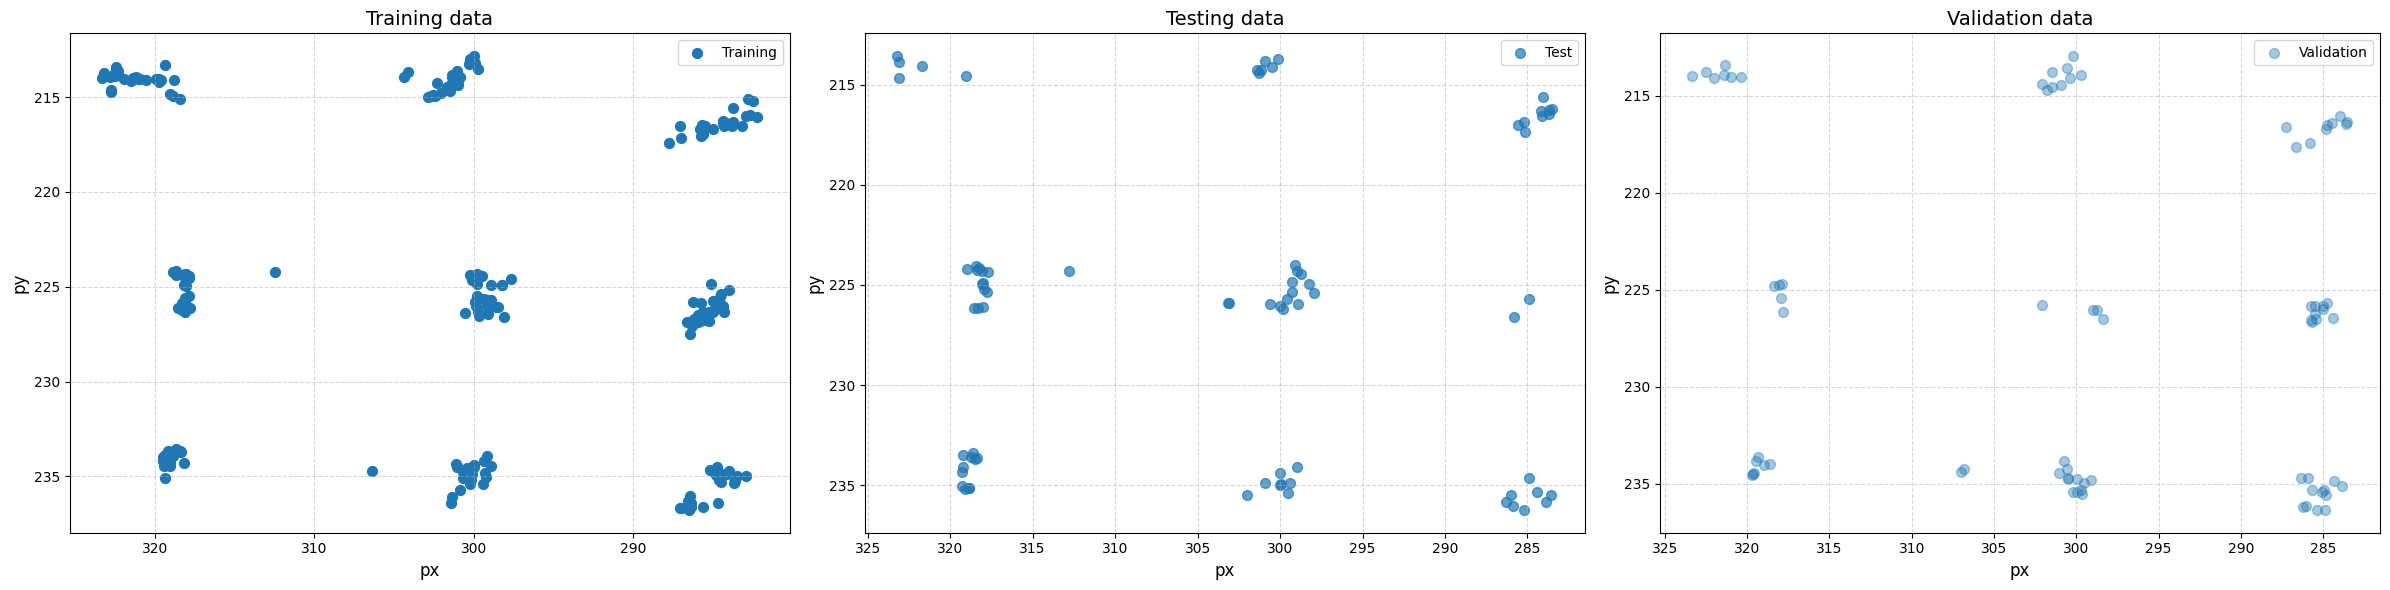

In [2]:
X_train, X_test, y_train, y_test = train_test_split(input, labels, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

nn_util.plot_data_splits(X_train, X_test, X_val) # uncomment once the splits are made


---
**Task 3 (easy): Reflection on data split💡**
1. Reflect on the benefits of making these splits and identify potential pitfals.


---

In [ ]:
#Write your reflection here...
# 1: splitting 20-20-69 for test-val-train is likely a good idea if you have enough data for this
# # to work. It allows you to do some hyper parameter tuning / early stopping using the val data, without compromising
# # the integrity of you performance on unseen data (i.e. test data)
# # For too small datasets, it may not be too good, as we may shrink the size og the training data too much.
# # Additionally, even though doing these splits can have various benefits, the samples are still taken generally
# # from the same single experiment and distribution, as we have talked about many times with the gaze data!

## Linear Model
In Assignment 1 Gaze Estimation
 Linear Least Square was used to find model parameters for a gaze estimation model.

---
**Task 4 (easy): Linear Least Square👩‍💻**
1. Run the cell below to learn the model parameters using Linear Least Squares on the entire gaze data training set and visualize the result.


---

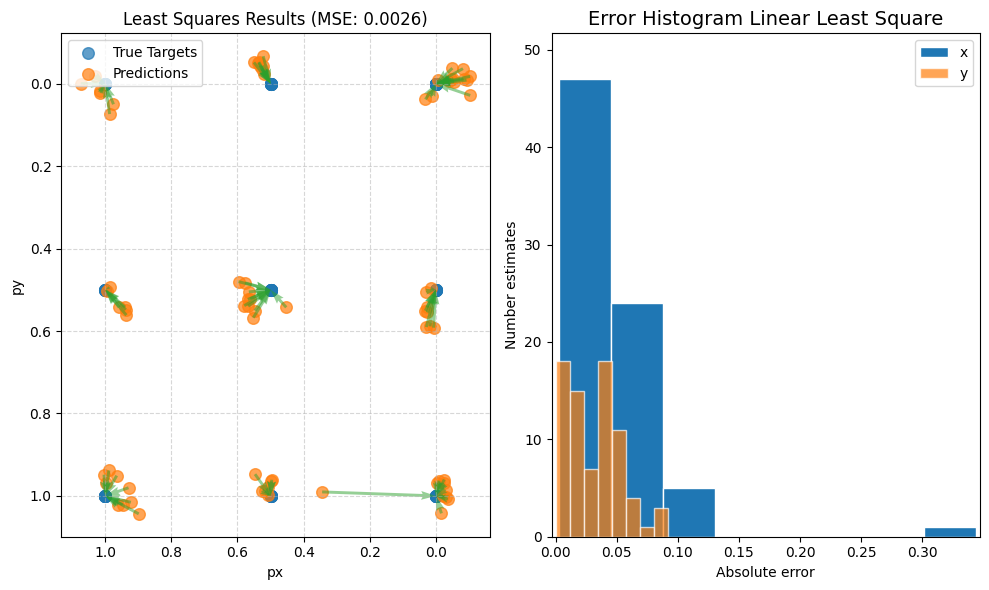

In [20]:
pred_l = nn_util.least_square(X_train, y_train, X_test)

nn_util.plot_least_square_results(pred_l, y_test)

The cell below contains the definition of an affine model in Pytorch.

---
**Task 5 (easy): Train a linear model (gaze data)👩‍💻**
1. On a piece of paper draw the architecture of the network given the class definition `LinearModel`
.
**Note:** The class `MSELoss`
 explicitly defines the _Mean Squared Error_ loss function, for pedagogical reasons. Note, the Pytorch library has its own mse loss
.


2. Run the cell below to train the network.


---


Average MSE: 150631.25


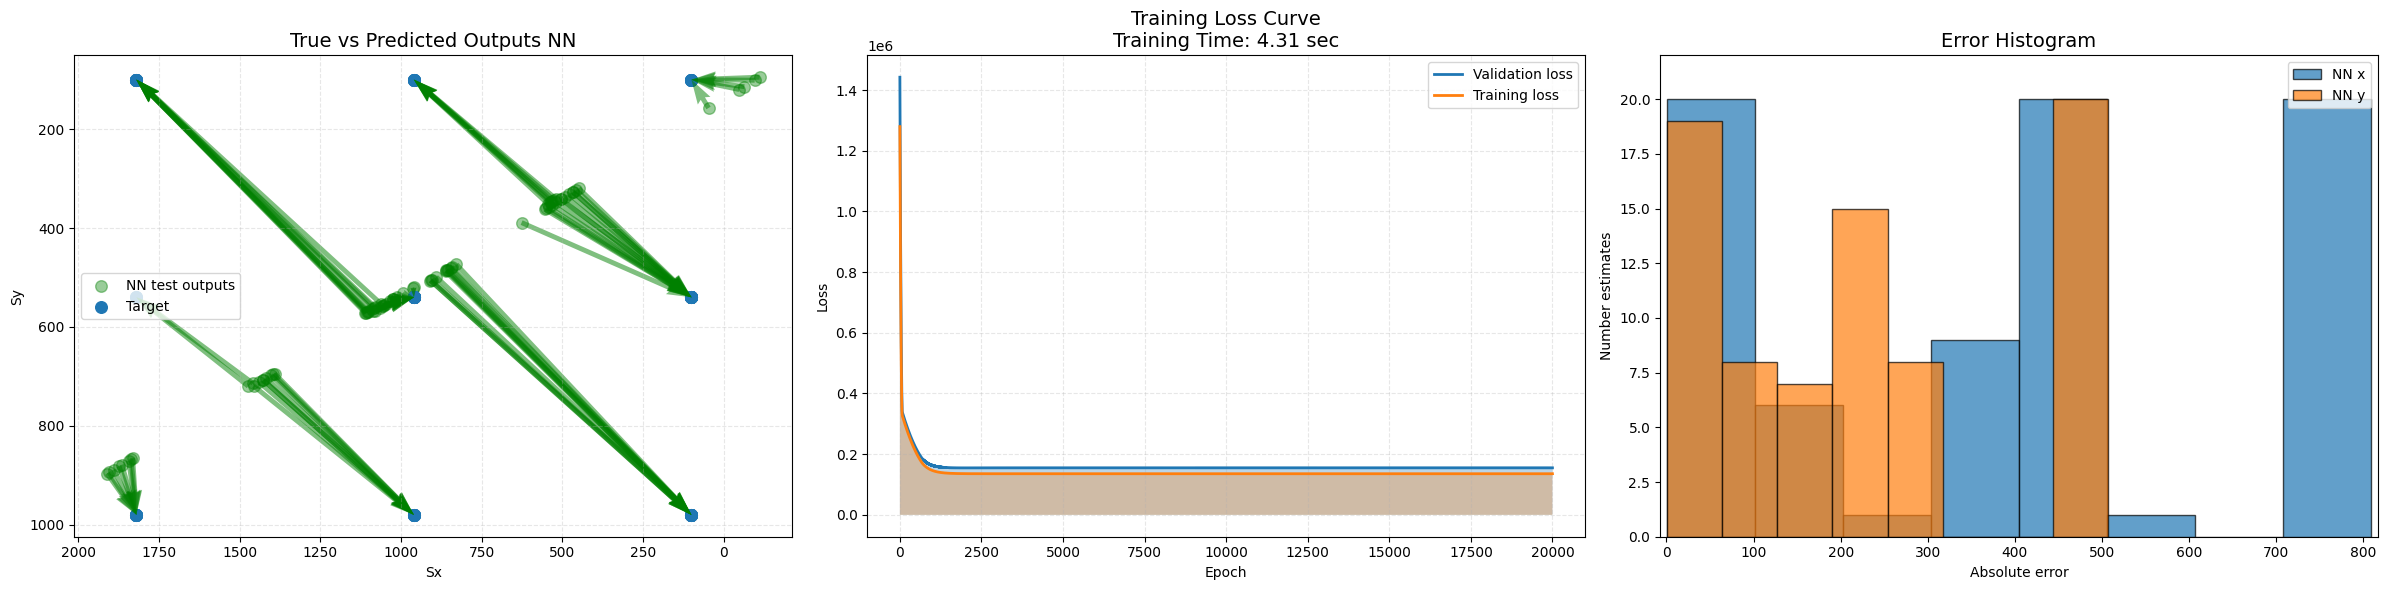

In [7]:
class LinearModel(nn.Module):
    """
    Args:
        input_dim (int): Number of input features.
        output_dim (int): Number of output features.

    Methods:
        forward(x): Passes the input through the linear layer.
    """
    def __init__(self, input_dim, output_dim):
        super(LinearModel, self).__init__()
        self.linear1 = nn.Linear(input_dim, output_dim)
 
    def forward(self, x):
        """Args:
        x (Tensor): Input tensor.
        Returns:
            Tensor: Output tensor after applying the linear transformation.
        """
        x = self.linear1(x)
        return x
    
class MSELoss(nn.Module):
    def __init__(self, reduction='mean'):
        super(MSELoss, self).__init__()
        self.reduction = reduction

    def forward(self, input, target):
        squared_diff = (input - target) ** 2
        if self.reduction == 'mean':
            return squared_diff.mean()
        elif self.reduction == 'sum':
            return squared_diff.sum()
        else:
            raise ValueError("Invalid reduction type. Use 'mean' or 'sum'.")

    
def train_model(model, criterion, optimizer, X_train, Y_train, X_val=None, Y_val=None, num_epochs=100):
    """
    Args:
        model (nn.Module): The neural network model to train.
        criterion (nn.Module): The loss function to minimize.
        optimizer (torch.optim.Optimizer): Optimizer for updating model parameters.
        X_train (Nx2 Tensor): Training input data.
        Y_train (Nx2 Tensor): Training target data.
        X_val (Nx2 Tensor, optional): Validation input data. Defaults to None.
        Y_val (Nx2 Tensor, optional): Validation target data. Defaults to None.
        num_epochs (int): Number of training epochs.

    Returns:
        list: Loss values for each epoch (training).
        list: Loss values for each epoch (validation).
        float: Training time.
    """
    start_time = time.time()
    train_losses = []
    val_losses = []
    model_params = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        train_losses.append(loss.item())


        with torch.no_grad():
            val_outputs = model(X_val)
            model_params.append(model.parameters())
            val_loss = criterion(val_outputs, Y_val)
            val_losses.append(val_loss.item())

    end_time = time.time()
    training_time = end_time - start_time

    return train_losses, val_losses, training_time



def test_model(model, X_test, Y_test):
    """
    Evaluates a trained model on test data.

    Args:
        model (nn.Module): The trained neural network model.
        X_test (Tensor): Test input data.
        Y_test (Tensor): Test target data.

    Returns:
        float: Mean squared error (MSE) over the test set.
        np.ndarray: Predicted values as a numpy array.
        np.ndarray: True values as a numpy array.
        np.ndarray: Absolute errors for x and y coordinates.
    """
    model.eval()
    with torch.no_grad():
        test_output = model(X_test)
        mse = mean_squared_error(Y_test.cpu().numpy(), test_output.cpu().numpy())
        predictions = test_output.cpu().numpy()
        true_values = Y_test.cpu().numpy()
        errors = np.abs(true_values - predictions)

    return mse, predictions, true_values, errors



# Set parameters
input_dim = 2
output_dim = 2
learning_rate = 0.1
epoch = 20000

# Generate training data
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(y_train, dtype=torch.float32)  
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(y_test, dtype=torch.float32)  
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(y_val, dtype=torch.float32)   

model = LinearModel(input_dim, output_dim)
criterion = MSELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Train the model
losses, val_losses, training_time = train_model(model, criterion, optimizer, X_train_tensor, Y_train_tensor, X_val_tensor, Y_val_tensor, num_epochs=epoch)

# Test the model
mse, Y_pred_lm, true_values, errors_nn = test_model(model, X_test_tensor, Y_test_tensor)
print(f'Average MSE: {mse}')

# Visualize results
nn_util.plot_results(
        Y_test_tensor,
        Y_pred_lm,
        errors_nn,
        losses,
        val_losses,
        model_name='NN',
        training_time=training_time
    )

You will notice, that the neural network has a difficulty in predicting gaze compared to the linear least square optimization. 

---
**Task 6 (easy): Analyse results💡**
1. Provide at least 3 reasons to why the neural network performs worse compared to the linear least squares. 


---

## Task 6: Analyze Results - Why Neural Network Performs Worse

### Reasons why the neural network performs worse compared to linear least squares:

**1. Optimization convergence issues:**
- **Linear Least Squares** finds the **optimal solution analytically** using the closed-form solution (normal equation: θ = (X^T X)^(-1) X^T y), which guarantees the global minimum for the MSE loss function.
- **Neural Network with SGD** uses **iterative optimization** (gradient descent) that may:
  - Not converge to the global optimum if learning rate is too high (overshooting) or too low (slow convergence)
  - Get stuck in local minima or saddle points (though for convex problems like linear regression, this is less likely)
  - Require many more iterations to reach the optimal solution than the number of epochs used
  - Stop training before reaching convergence, especially if early stopping is used or if the number of epochs is insufficient

**2. Learning rate and hyperparameter sensitivity:**
- The neural network's performance is **highly dependent on hyperparameters**, particularly the learning rate:
  - If learning rate is too large: the optimizer may overshoot the minimum, causing oscillations or divergence
  - If learning rate is too small: convergence is very slow, and training may stop before reaching the optimum
  - Linear least squares has no such hyperparameters - it directly computes the optimal solution
- Other hyperparameters like batch size (if using mini-batch SGD) can also affect convergence speed and final performance

**4. Stochastic nature of gradient descent:**
- **SGD introduces randomness** through:
  - Random initialization of weights (though for a linear model, this is less critical)
  - Stochastic sampling if using mini-batch gradient descent (random batches)
  - This randomness can lead to suboptimal solutions or slower convergence compared to the deterministic analytical solution
- Linear least squares is **completely deterministic** - given the same data, it always produces the same optimal result

**5. Numerical precision and stability:**
- **Linear least squares** (when implemented with stable matrix operations like SVD or QR decomposition) can handle numerical issues more robustly
- **Gradient descent** may suffer from:
  - Numerical precision issues in gradient computation
  - Accumulation of rounding errors over many iterations
  - Potential issues with ill-conditioned matrices (though this affects both methods)

**6. Overfitting to training data (less likely but possible):**
- While less common for a simple linear model, if the neural network training is not properly regularized or if there are implementation differences, it might:
  - Overfit to noise in the training data
  - Not generalize as well as the analytical solution
- Linear least squares with the standard formulation finds the solution that minimizes training MSE, which is optimal for the training set

**Key insight:**
For a **linear regression problem** (which is what both methods are solving when using a single linear layer), linear least squares is theoretically superior because:
- It finds the **exact optimal solution** in one step
- It has **no hyperparameters** to tune
- It is **guaranteed to converge** to the global minimum (for convex MSE loss)
- It is **computationally efficient** for the problem size

The neural network approach, while more flexible and generalizable to non-linear problems, is overkill for this simple linear case and introduces optimization challenges that the analytical solution avoids.

## Improving performance
The following steps will investigate reasons for the poorer performance and include:
- Data scale
- The learning rate
- The number of iterations

### Data wrangling
The following step investigate the impact of preprocessing of the data by normalizing the input and label data. It also investigates the impact of the learning rate and the number of iterations through `grid search`
.

**Data structure for plotting**
To investigate the performance of the models the function `plot_results_collected`
 from the file `nn_util.py`
 is used. This function takes six dictionaries with models version as key containing the following for each model trained:
- Model instance (object)
- List of training losses (float)
- List of validation losses (float)
- Training time (float)
- $N \times 2$ array of predictions on test data (float)
- List of prediction errors (float)

The data needed to populate these data structures is provided gradually througout the exercise. It is important to name the models based on the data and hyper parameters used.


---
**Task 7 (easy): Train a linear model (normalized gaze data and synthetid gaze data)👩‍💻**
1. Complete the `DataScaler`
 class by implementing the `normalize`
 function and the `denormalize`
 function. 


$$
x_{\text{normalized}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

$$
x_{\text{denormalized}} = x_{\text{normalized}} \cdot (x_{\max} - x_{\min}) + x_{\min}
$$
2. Use `DataScaler`
to normalize the data in the `pupil_coordinates.csv`
 and `screen_coordinates.csv`
 files.
3. The nested for-loops performs grid search of hyper parameter settings. In the nested for-loops:    - Train a model on the normalized data using the `train_model`
 function.
    - Test the model using the `test_model`
 function.
    - For each model store results in the designated dictionaries:        - Model instance (`LinearModel`
)
        - Loss (training)
        - Loss (validation)
        - Training time
        - Predictions for test data 
        - Prediction errors 




4. Use the function `plot_results_collected`
 from the `nn_util.py`
 file, to visualize the result.


---

In [8]:
class DataScaler:
    def __init__(self):
        self.min = None
        self.max = None

    def normalize(self, data):
        self.min = min(data)
        self.max = max(data)
        return [(x - self.min) / (self.max - self.min) for x in data]

    def denormalize(self, normalized_data):
        return [x_norm * (self.max - self.min) + self.min for x_norm in normalized_data]

In [10]:
# Normalize the full input and labels data BEFORE splitting

# Normalize input data (pupil coordinates) - normalize each column separately
scaler_input_x = DataScaler()
scaler_input_y = DataScaler()

input_normalized_x = scaler_input_x.normalize(input[:, 0].tolist())
input_normalized_y = scaler_input_y.normalize(input[:, 1].tolist())

# Combine normalized input
input_normalized = np.column_stack([input_normalized_x, input_normalized_y])

# Normalize output data (screen coordinates/labels) - normalize each column separately
scaler_labels_x = DataScaler()
scaler_labels_y = DataScaler()

labels_normalized_x = scaler_labels_x.normalize(labels[:, 0].tolist())
labels_normalized_y = scaler_labels_y.normalize(labels[:, 1].tolist())

# Combine normalized labels
labels_normalized = np.column_stack([labels_normalized_x, labels_normalized_y])

# Now split the normalized data (same way as Task 2)
X_train, X_test, y_train, y_test = train_test_split(input_normalized, labels_normalized, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

# Convert to tensors for training
X_train_tensor_norm = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor_norm = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor_norm = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor_norm = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor_norm = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor_norm = torch.tensor(y_test, dtype=torch.float32)

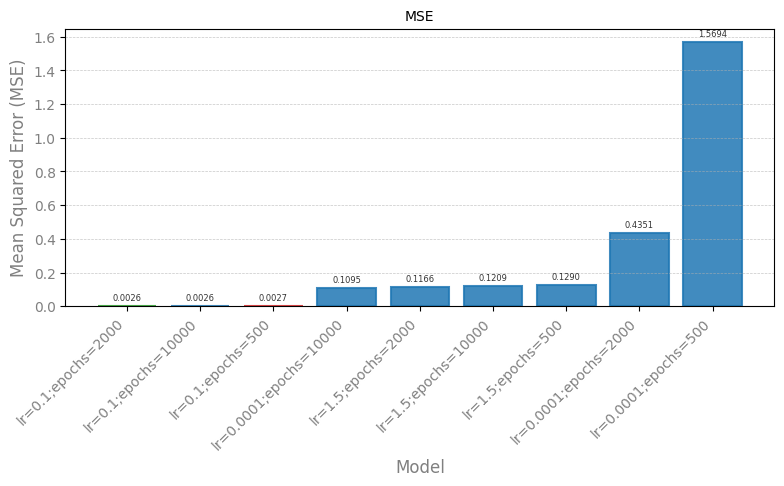

In [12]:
# Set hyperparameters
input_dim = 2
output_dim = 2
learning_rate = [0.0001, 0.1, 1.5]
epoch = [500, 2000, 10000]
criterion = MSELoss()

# Containers gaze data
models_dict = {}
losses_train_dict = {}
losses_val_dict = {}
training_time_dict = {}
pred_norm_dict = {}
errors_norm_dict = {}
mse_norm_dict= {}


#Train the models
for lr in learning_rate:
    for e in epoch:
        model = LinearModel(input_dim, output_dim)
        criterion = MSELoss()
        optimizer = optim.SGD(model.parameters(), lr=lr)

        # Train the model
        losses, val_losses, training_time = train_model(model, criterion, optimizer, X_train_tensor_norm, Y_train_tensor_norm, X_val_tensor_norm, Y_val_tensor_norm, num_epochs=e)

        # Test the model
        mse, Y_pred_lm, true_values, errors_nn = test_model(model, X_test_tensor_norm, Y_test_tensor_norm)

        key = f"lr={lr};epochs={e}"
        models_dict[key] = model
        losses_train_dict[key] = losses
        losses_val_dict[key] = val_losses
        training_time_dict[key] = training_time
        pred_norm_dict[key] = Y_pred_lm
        errors_norm_dict[key] = errors_nn
        mse_norm_dict[key] = mse


nn_util.plot_mse_bar(mse_norm_dict)

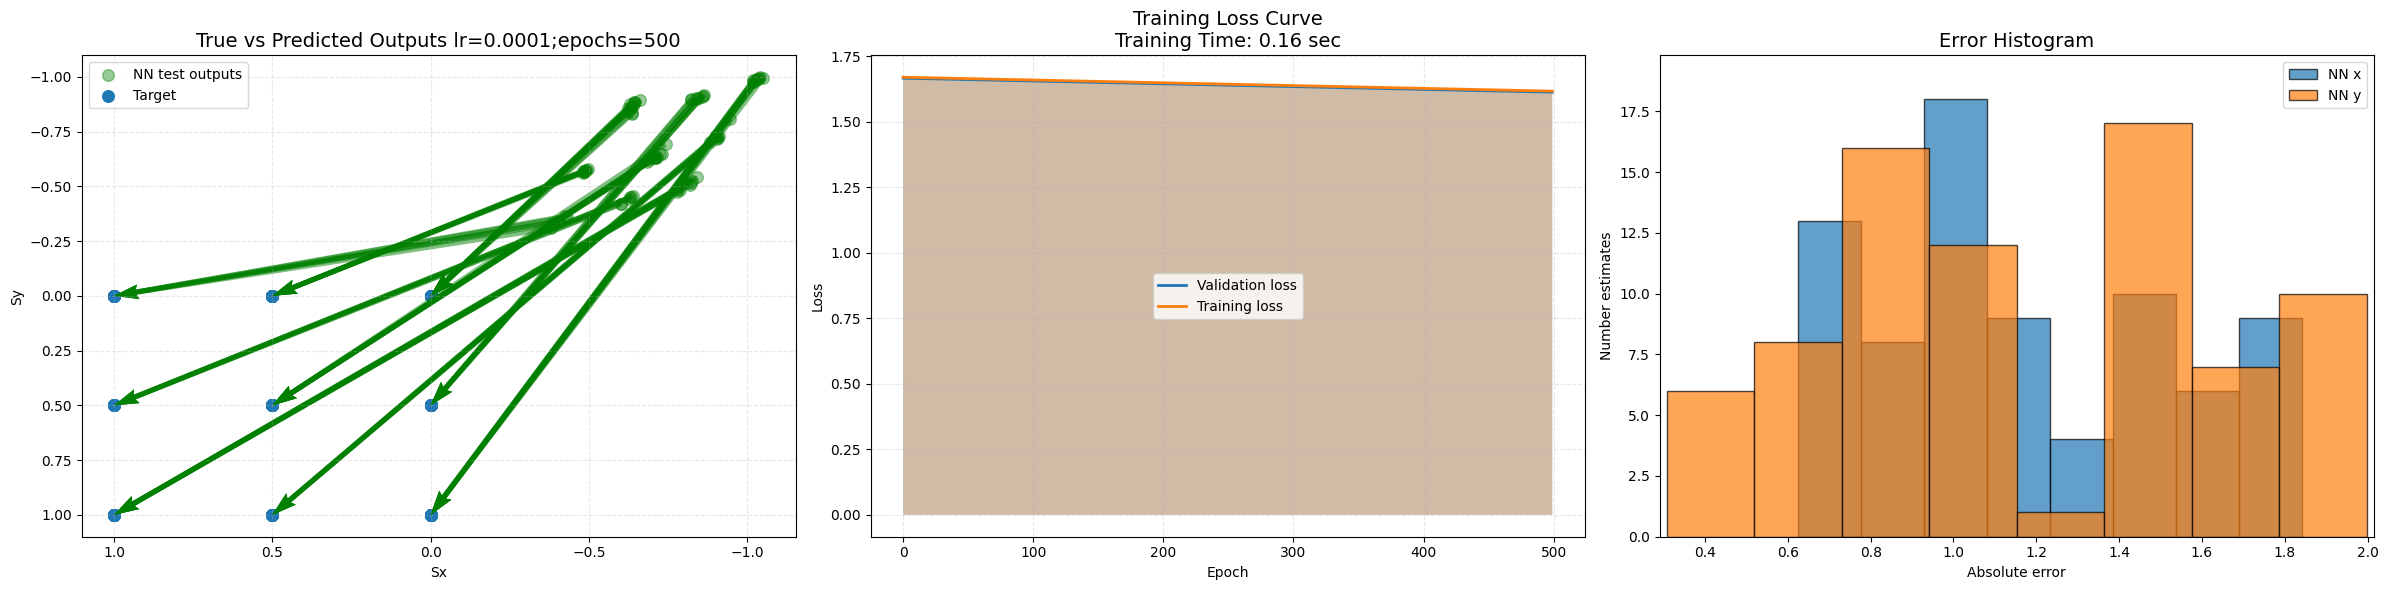

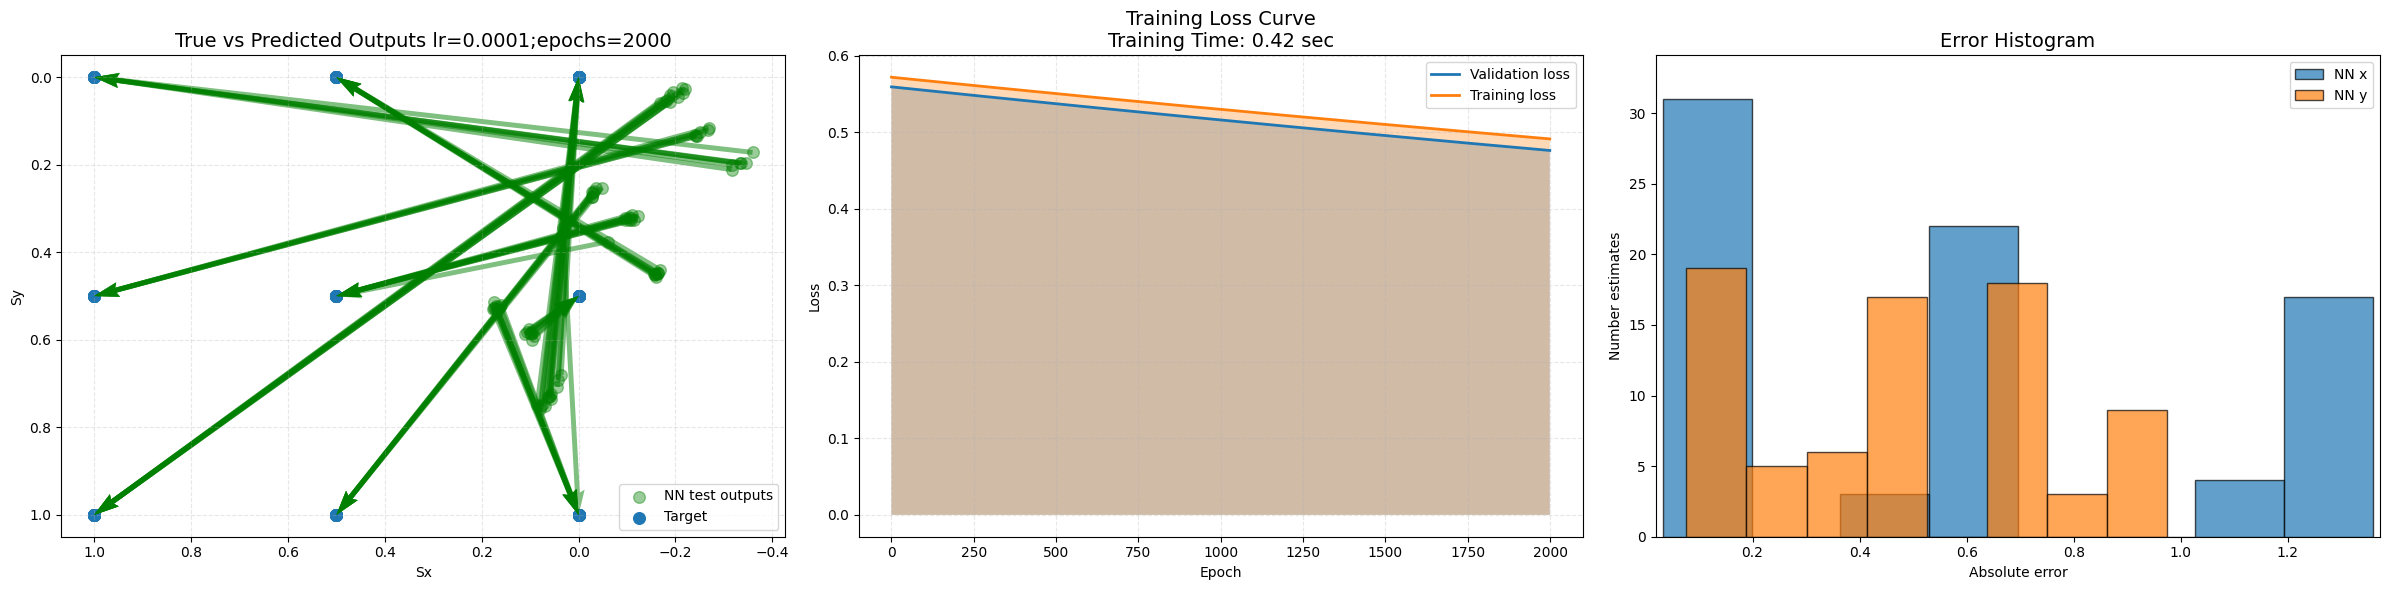

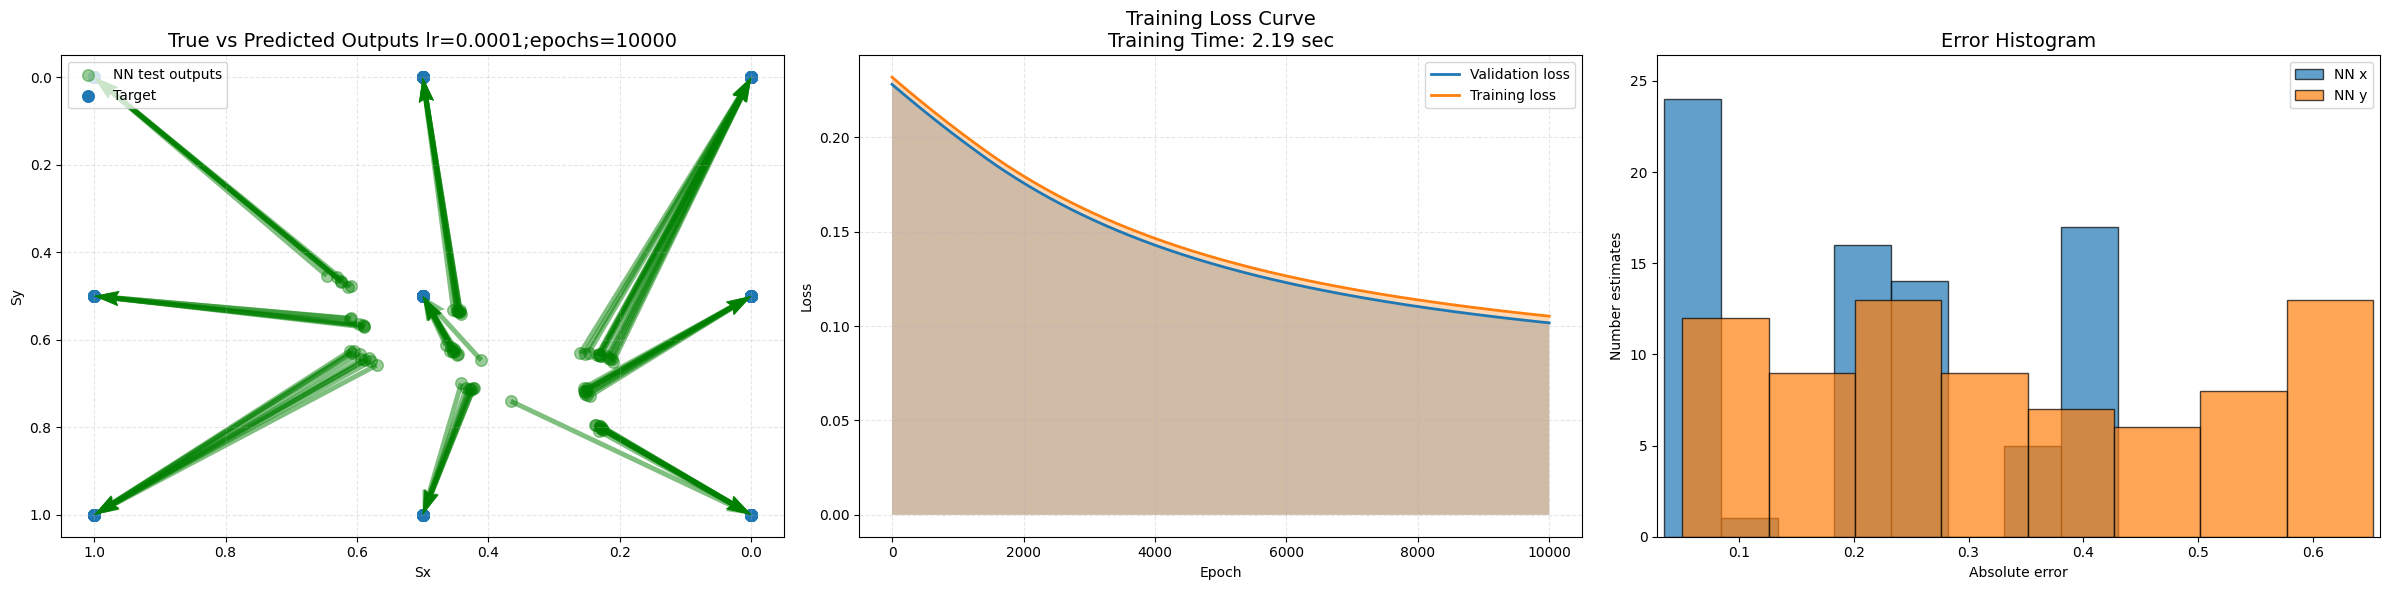

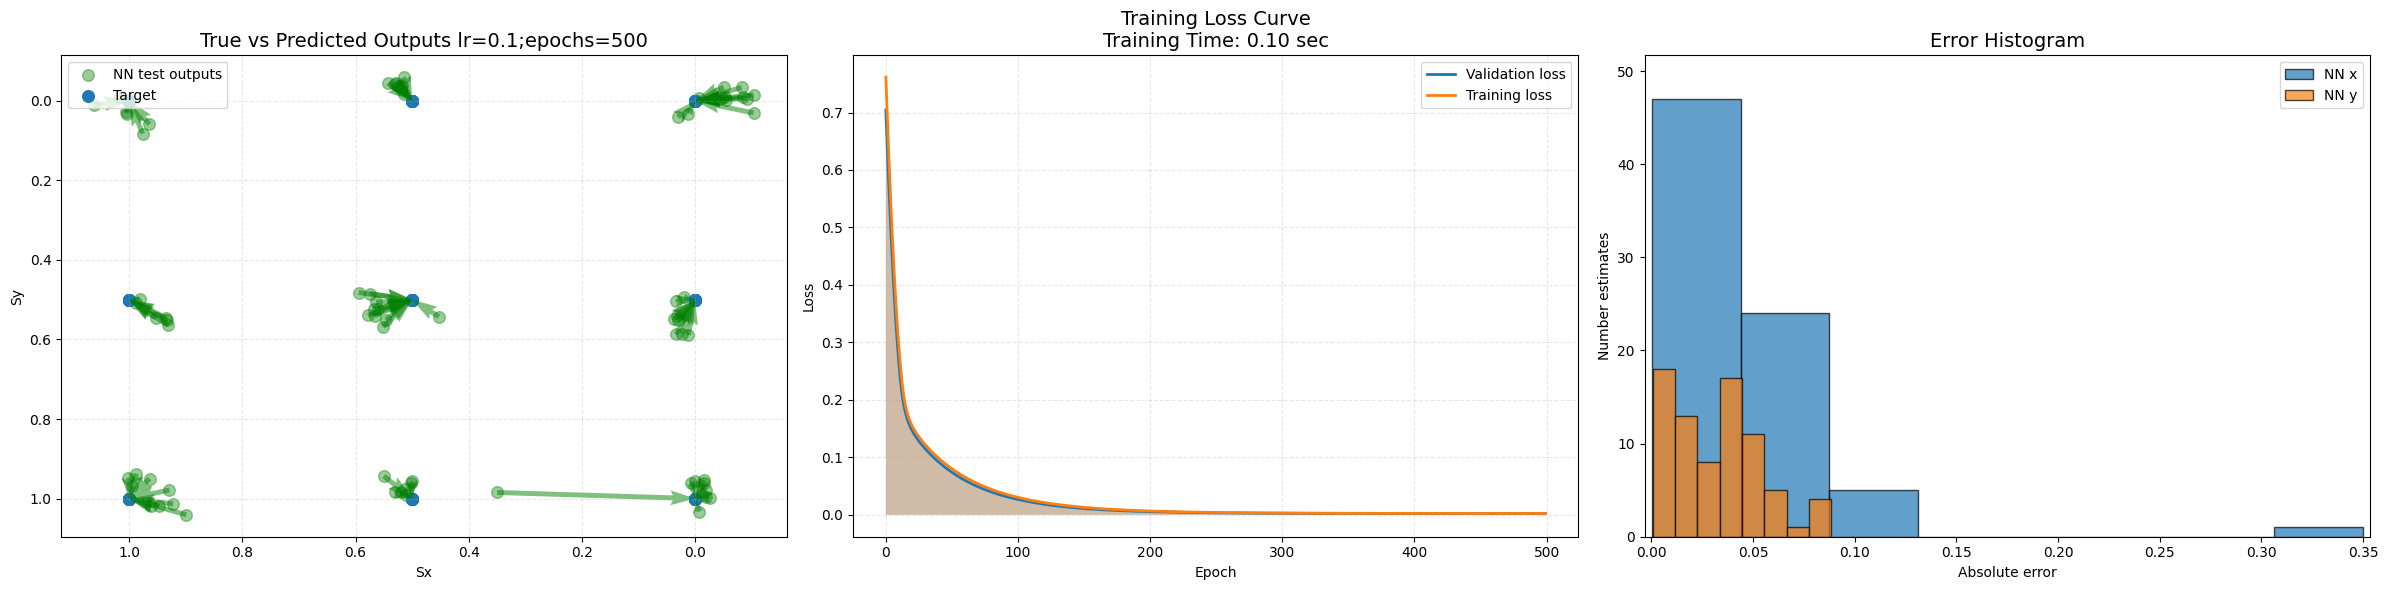

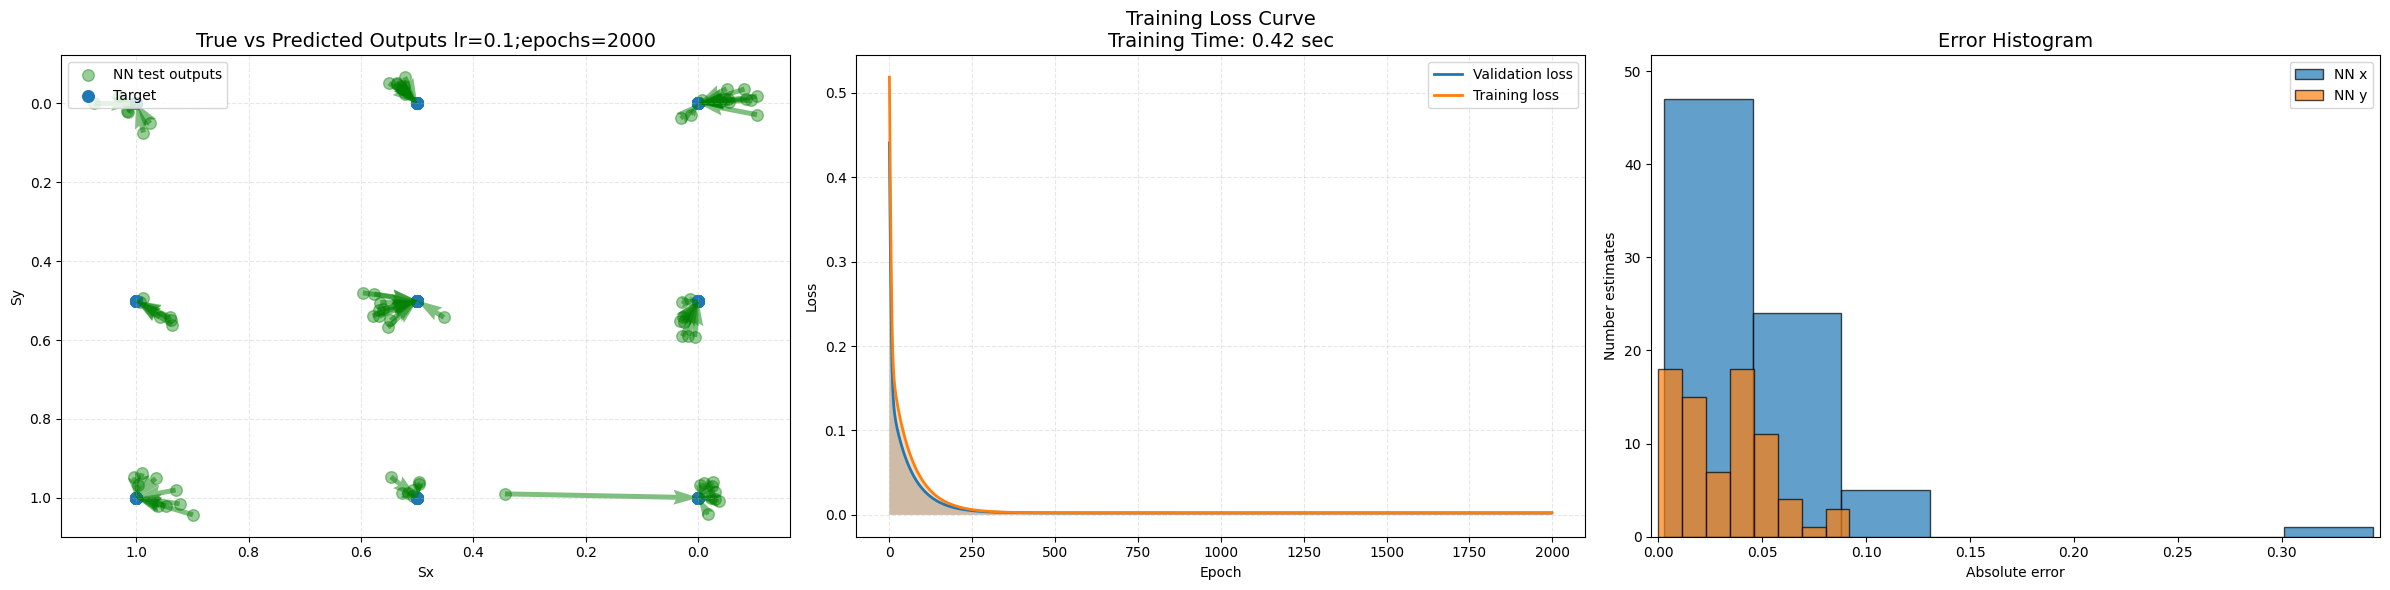

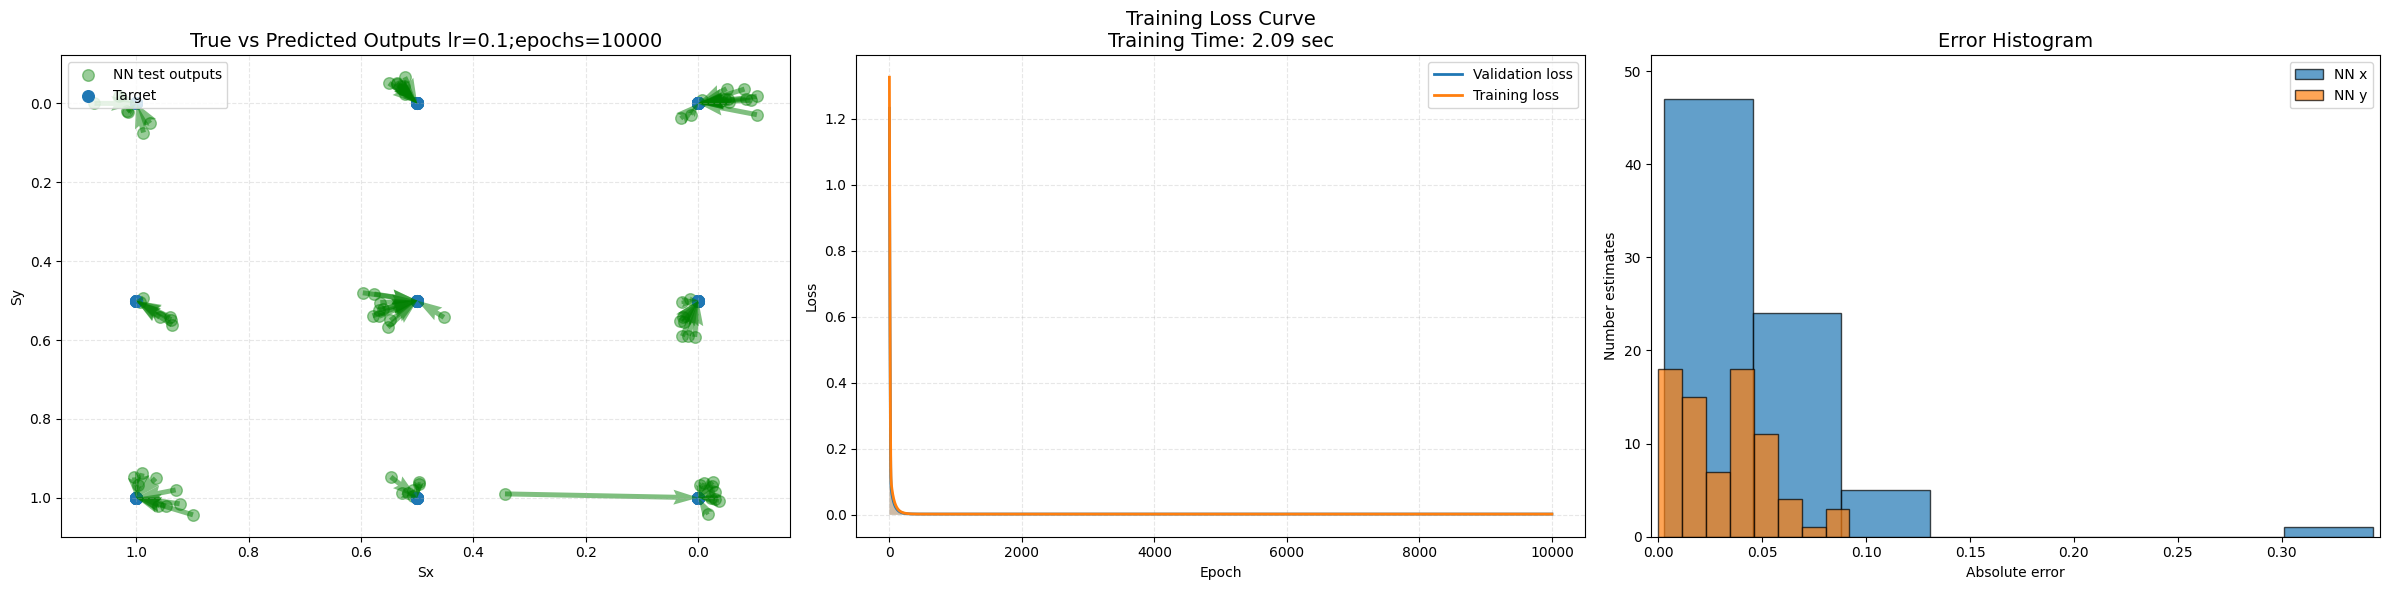

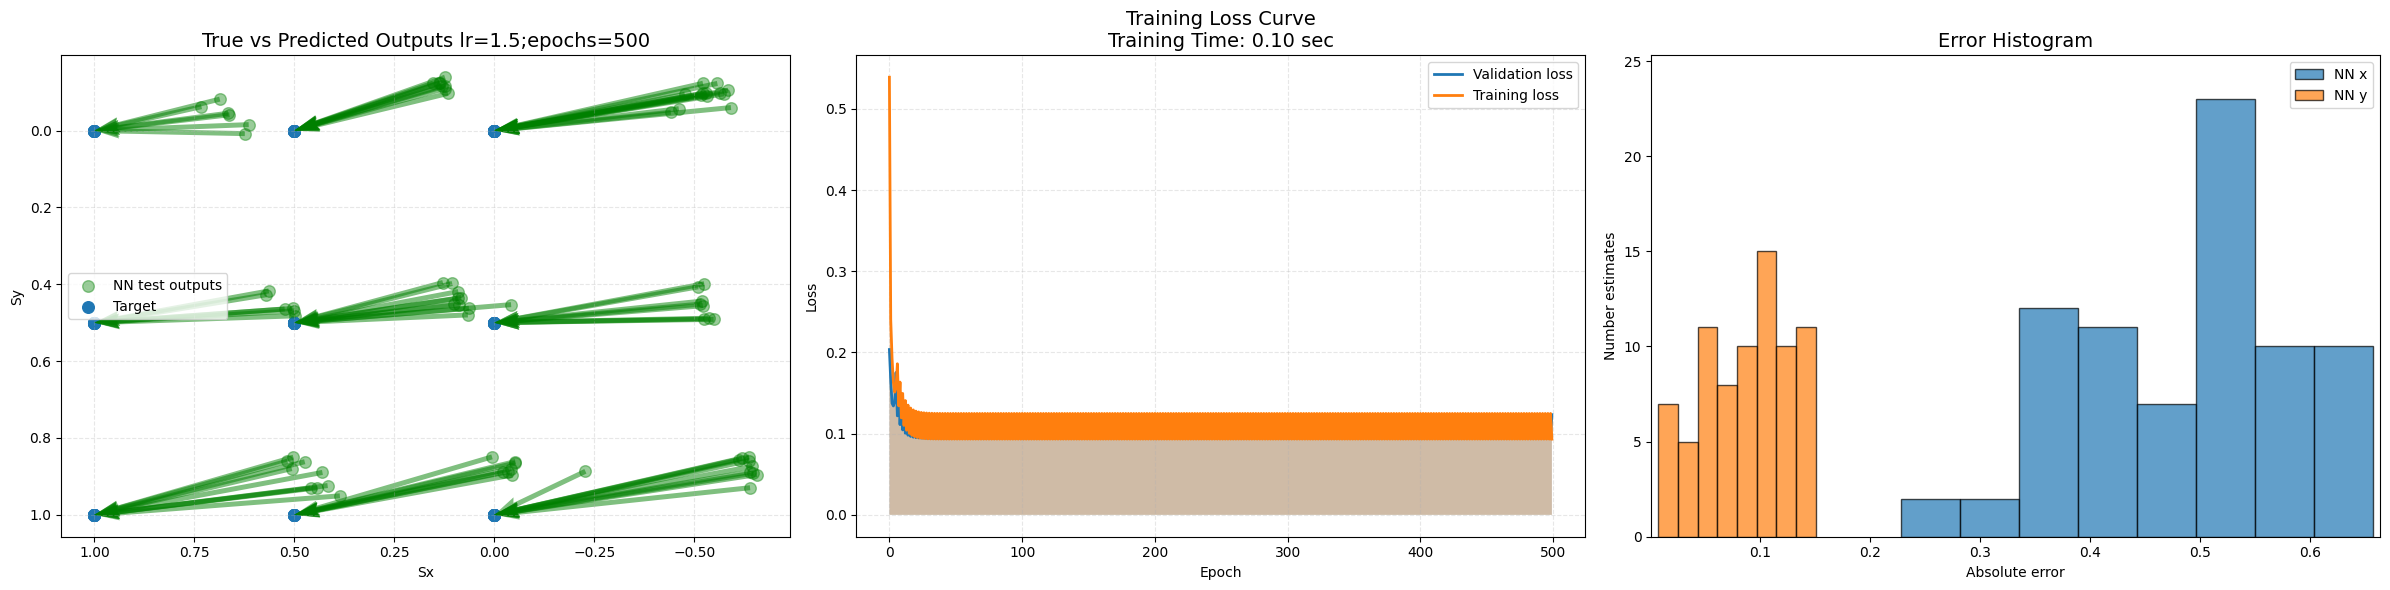

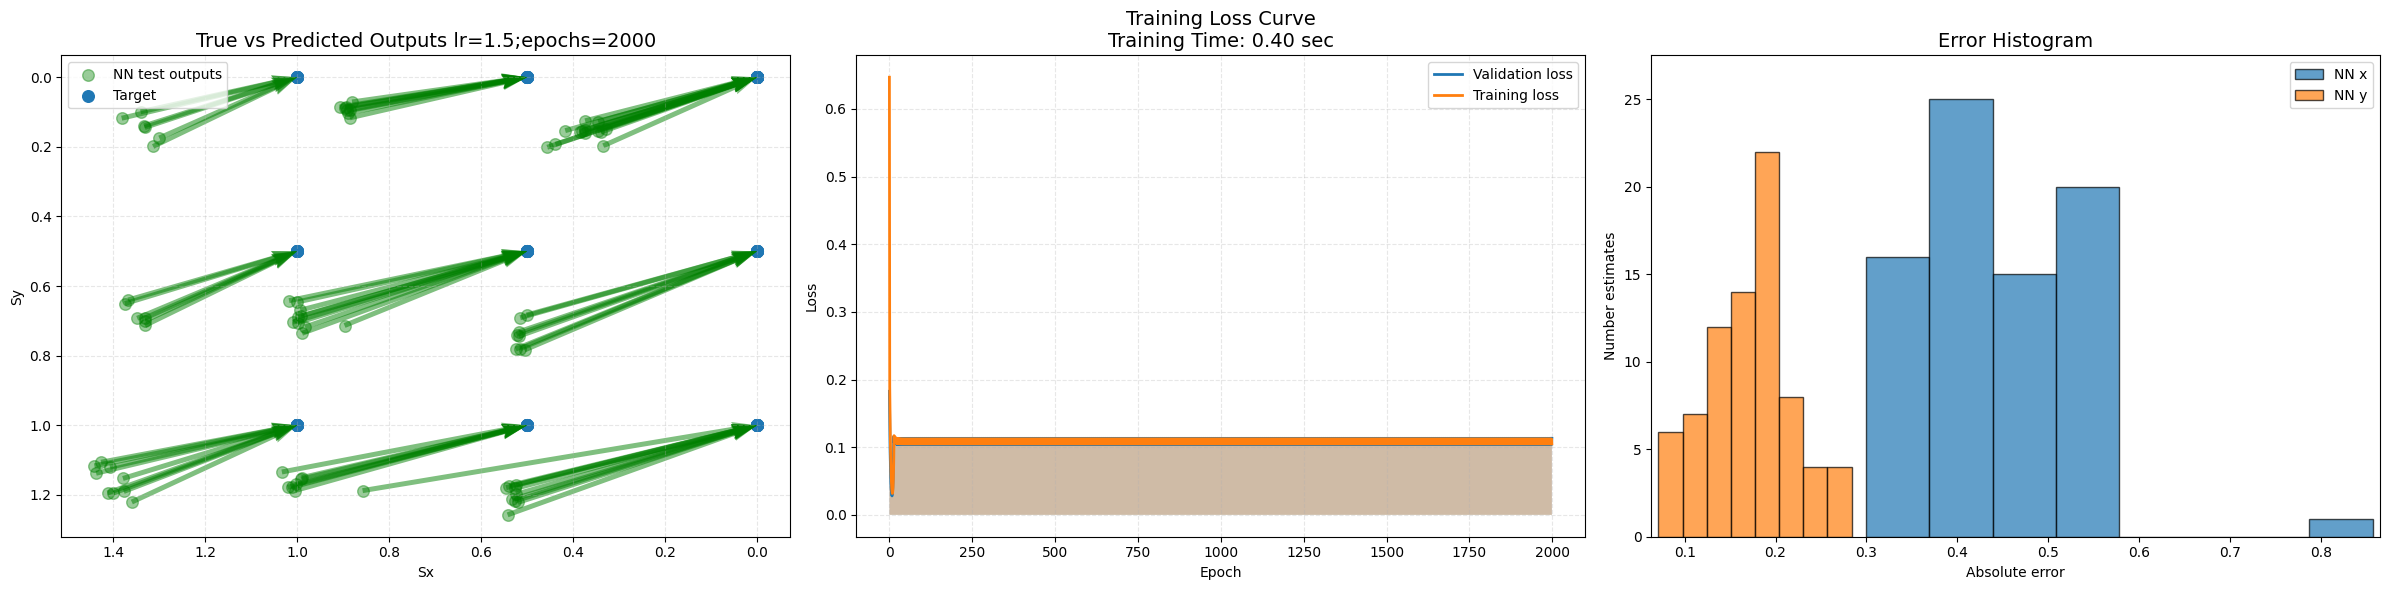

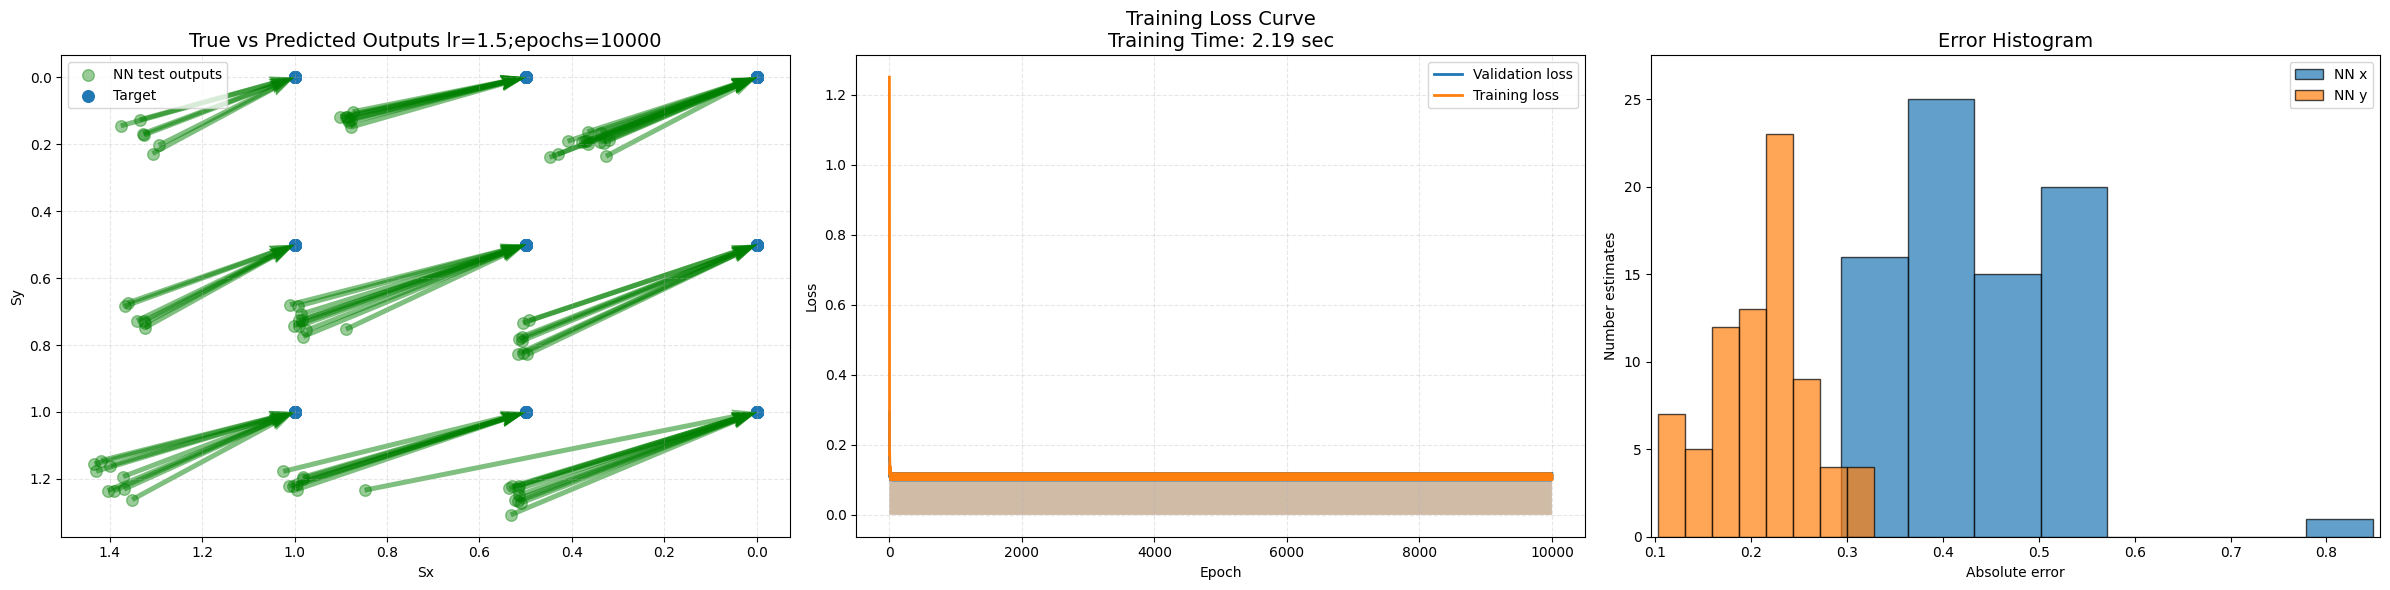

In [ ]:
nn_util.plot_results_collected(
    Y_test_tensor_norm, pred_norm_dict,
    errors_norm_dict, models_dict,
    losses_train_dict, losses_val_dict, training_time_dict
)


---
**Task 8 (easy): Reflection on results💡**
1. What is the impact of normalizing the data and why?
2. Experiment with the hyperparameter settings in the `learning_rate`
 and number of `epoch`
 lists.
3. What are the benefits and cost of training with larger/smaller learning rate? Reflect on the effect of changing the learning rate.
4. Reflect on the effect of the loss and training time when changing the number of epochs. 
5. What is the relationship between learning rate and epochs? 
6. The network architecture mimics the charateristics of a linear model, explain why the network architecture in many instances performs much different (and worse) compared to the linear least square?


---

## Task 8: Reflection on Results

### 1. What is the impact of normalizing the data and why?

**Impact of normalization:**

- **Improved convergence**: Normalization significantly improves the training speed and convergence of the neural network. The optimizer (SGD) can reach the optimal solution much faster with normalized data.

- **Stable gradient updates**: When features are on different scales, gradients can be very different in magnitude. Normalization ensures all features contribute equally to the gradient updates, preventing one feature from dominating the learning process.

- **Better learning rate effectiveness**: With normalized data, a single learning rate can work well for all features. Without normalization, features with larger scales might require different learning rates, making optimization more difficult.

- **Reduced numerical instability**: Normalization prevents issues with very large or very small values that can cause numerical overflow or underflow during computation.

- **Faster training**: The network typically requires fewer epochs to converge when data is normalized, reducing training time.

**Why normalization helps:**
- Neural networks are sensitive to the scale of input features. When features have different scales (e.g., pupil coordinates might range from -1000 to 1000, while normalized values range from 0 to 1), the loss landscape becomes elongated and optimization becomes difficult.
- Normalization transforms all features to a similar scale (typically [0, 1] or [-1, 1]), creating a more "spherical" loss landscape that is easier to optimize.
- For linear models, this is especially important because the weights need to be learned through gradient descent, and unbalanced scales make this process inefficient.

### 2. Experiment with the hyperparameter settings in the `learning_rate` and number of `epoch` lists.

**Observations from experiments:**

- **Learning rate effects:**
  - Very small learning rates (e.g., 0.0001): Slow convergence, may not reach optimal solution within given epochs, but stable training
  - Moderate learning rates (e.g., 0.1): Good balance between convergence speed and stability
  - Large learning rates (e.g., 1.5): May cause oscillations, overshooting, or divergence; training becomes unstable

- **Epoch effects:**
  - Too few epochs (e.g., 500): Model may not converge, underfitting, high loss
  - Moderate epochs (e.g., 2000): Good convergence for appropriate learning rates
  - Many epochs (e.g., 10000): May lead to overfitting if learning rate is too small, or may converge well if learning rate is appropriate

- **Combination effects:**
  - Small LR + Many epochs: Slow but stable convergence, may eventually reach good solution
  - Large LR + Few epochs: May diverge or oscillate, poor performance
  - Moderate LR + Moderate epochs: Often best balance

### 3. What are the benefits and costs of training with larger/smaller learning rate? Reflect on the effect of changing the learning rate.

**Small learning rate:**

**Benefits:**
- **Stability**: Training is more stable, less likely to overshoot the minimum or diverge
- **Precise convergence**: Can reach very precise solutions near the global minimum
- **Smooth optimization**: Gradient updates are small and controlled, leading to smooth loss curves

**Costs:**
- **Slow convergence**: Requires many more epochs to reach the optimal solution
- **Computational cost**: Longer training time
- **Risk of getting stuck**: May get stuck in shallow local minima or saddle points
- **Underfitting risk**: May stop training before reaching optimal solution if epoch budget is limited

**Large learning rate:**

**Benefits:**
- **Fast initial progress**: Makes large steps toward the minimum, can converge quickly
- **Escape local minima**: Large steps can help escape shallow local minima
- **Computational efficiency**: Fewer epochs needed if it converges

**Costs:**
- **Instability**: Can overshoot the minimum, causing oscillations or divergence
- **Loss of precision**: May converge to a suboptimal solution near but not at the minimum
- **Training failure**: Can cause the loss to explode (NaN values) or diverge completely
- **Oscillations**: Loss may bounce around the minimum without settling

**Effect of changing learning rate:**
- The learning rate controls the step size in gradient descent. Too small → slow convergence, too large → instability. The optimal learning rate depends on the loss landscape, which is affected by data normalization, model architecture, and the specific optimization problem.

### 4. Reflect on the effect of the loss and training time when changing the number of epochs.

**Effect on loss:**

- **Too few epochs:**
  - Training loss: High, model hasn't learned enough
  - Validation loss: High, poor generalization
  - Test loss: High, poor performance
  - The model is underfitted

- **Appropriate number of epochs:**
  - Training loss: Decreases and stabilizes at a low value
  - Validation loss: Decreases and stabilizes, similar to training loss
  - Test loss: Low, good generalization
  - The model has converged to a good solution

- **Too many epochs (with appropriate learning rate):**
  - Training loss: May continue to decrease slightly
  - Validation loss: Should remain stable (for linear models, overfitting is less of an issue)
  - Test loss: Should remain stable
  - For linear models, more epochs typically don't hurt (unlike complex models that can overfit)

**Effect on training time:**

- **Linear relationship**: Training time increases linearly with the number of epochs (each epoch processes the same amount of data)
- **Trade-off**: More epochs → better convergence but longer training time
- **Diminishing returns**: After convergence, additional epochs don't improve performance but continue to consume time

**Key insight:**
For a linear model with normalized data, there's typically a "sweet spot" of epochs where the model converges. Beyond this point, more epochs don't significantly improve performance but increase computational cost. The optimal number depends on the learning rate - smaller learning rates require more epochs.

### 5. What is the relationship between learning rate and epochs?

**Inverse relationship for convergence:**

- **Small learning rate ↔ Many epochs**: When learning rate is small, many epochs are needed to reach convergence. The model makes small steps, so it needs many steps to reach the minimum.

- **Large learning rate ↔ Few epochs**: When learning rate is large, fewer epochs may be needed IF the learning rate is stable. However, large learning rates often cause instability, requiring careful tuning.

**Compensation:**

- You can compensate for a small learning rate by increasing epochs (more time, but stable)
- You can compensate for a large learning rate by decreasing epochs (faster, but risky)

**Optimal combination:**

- The best results typically come from a **moderate learning rate** (not too small, not too large) combined with **sufficient epochs** to allow convergence
- For normalized data, a learning rate around 0.01-0.1 often works well with 1000-5000 epochs for linear models

**Mathematical relationship:**

- The total "distance" the optimizer travels is approximately: `learning_rate × number_of_updates × average_gradient_magnitude`
- To reach the same solution, if you halve the learning rate, you roughly need to double the epochs (though this is simplified - gradients change as you approach the minimum)

**Practical implications:**

- If training is slow, you can try increasing learning rate (carefully) rather than just adding more epochs
- If training is unstable, reduce learning rate and increase epochs
- The relationship is not perfectly linear due to changing gradients, but the general principle holds

### 6. The network architecture mimics the characteristics of a linear model, explain why the network architecture in many instances performs much different (and worse) compared to the linear least square?

**Why the neural network performs worse despite being equivalent:**

**1. Optimization method differences:**
- **Linear Least Squares**: Uses analytical solution (normal equation or matrix decomposition) that finds the **exact global minimum** in one step
- **Neural Network**: Uses iterative optimization (gradient descent) that may:
  - Not converge to the global minimum within the given epochs
  - Converge to a suboptimal solution near but not at the minimum
  - Get stuck due to insufficient training time or poor hyperparameters

**2. Convergence issues:**
- Even though the architecture is linear, the optimization process may not complete:
  - Learning rate might be too small → slow convergence → stops before optimal
  - Learning rate might be too large → instability → diverges or oscillates
  - Number of epochs might be insufficient → training stops before convergence

**3. Numerical precision:**
- **Linear Least Squares**: Uses highly optimized numerical linear algebra libraries (SVD, QR decomposition) that are very stable and precise
- **Gradient Descent**: Accumulates rounding errors over many iterations, potentially leading to less precise solutions

**4. Initialization sensitivity:**
- While less critical for linear models, the initial weights can affect convergence speed and final solution quality
- Linear least squares has no initialization - it directly computes the solution

**5. Hyperparameter dependency:**
- The neural network's performance is **highly dependent** on learning rate and number of epochs
- Linear least squares has **no hyperparameters** - it always finds the optimal solution

**6. Stopping criteria:**
- Neural network training stops after a fixed number of epochs, which may be before convergence
- Linear least squares computes until completion (which is always one step for the analytical solution)

**7. Loss landscape interpretation:**
- For linear regression, the loss is convex, so both methods should find the same solution
- However, gradient descent may take a "zigzag" path to the minimum, potentially stopping before reaching it
- The analytical solution goes directly to the minimum

**Key insight:**
Even though the neural network architecture is mathematically equivalent to linear regression, the **optimization process** is fundamentally different. The analytical solution (linear least squares) is superior for this specific problem because it guarantees the optimal solution with no hyperparameter tuning. The neural network approach introduces optimization challenges (learning rate, epochs, convergence) that the analytical method avoids entirely.

**When neural networks would be better:**
- For non-linear problems where analytical solutions don't exist
- When you need the flexibility to add non-linear layers later
- For very large datasets where computing the analytical solution is computationally expensive

## Non-linear Model
The following steps are about two different architectures for non-linear models. Compare the non-linear models to the affine model as done above. 

---
**Task 9 (easy): Analyse architecture💡**
1. Examine the cell below to get an overview of the two model architectures and identify the main differences between the models.


---

In [15]:
class NNRelu(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NNRelu, self).__init__()
        self.linear1 = nn.Linear(input_dim, output_dim)
        self.relu = nn.ReLU()
 
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        return x
 
class NNRelu_exp(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NNRelu_exp, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()
        self.linear3 = nn.Linear(hidden_dim, output_dim)
 
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu1(x)
        x = self.linear2(x)
        x = self.relu2(x)
        x = self.linear3(x)
        return x

In [0]:
# Write your reflections here...
# Version 1 has no hidden layers but adds an activation function to the linear combination
# Version 2 has 2 hidden layers, moving to a more complex space of more complex functions.


---
**Task 10 (easy): Train non-linear models (cleaned gaze data)👩‍💻**
**Note:** For the exam it may be convenient to copy the code from above to the cell below as you complete the steps. 

1. Rerun task [Task 7](#prediction100) using the normalized to train two new models. The steps are:

- Train the models:
    - Create two nested for-loops looping the lists containing hyperparameter values for `learning rate`
 and `epochs`
. The loops should:        - Train models of both architectures on the cleaned normalized data, using the `train_model`
 function.
        - Test the models using the `test_model`
 function.
        - Save the following information in the designated dictionaries with the suffix `arc`
, for each model:            - Model 
            - Loss (training)
            - Loss (validation)
            - Training time 
            - Predictions
            - Errors 






- Use the function `plot_results_collected`
 from the `nn_util.py`
 file, to visualize the result.

- Use the function `plot_mse_bar`
 from the `nn_util.py`
 file, to visualize the mean squared error compared.



---

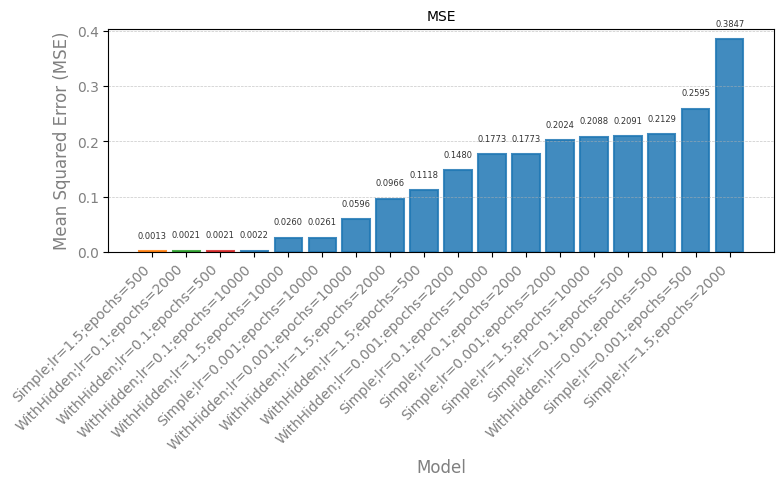

In [18]:
# Set hyperparameters
input_dim = 2
output_dim = 2
learning_rate = [0.001, 0.1, 1.5]
epoch = [500, 2000, 10000]
hidden_layer = 10

criterion = MSELoss()

models_dict_arc = {}
losses_dict_arc = {}
losses_val_dict_arc = {}
training_time_dict_arc = {}
pred_norm_arc = {}
errors_norm_arc = {}
mse_arc = {}

#Train the models
for lr in learning_rate:
    for e in epoch:
        model = NNRelu(input_dim, output_dim)
        optimizer = optim.SGD(model.parameters(), lr=lr)

        # Train the model
        losses, val_losses, training_time = train_model(model, criterion, optimizer, X_train_tensor_norm, Y_train_tensor_norm, X_val_tensor_norm, Y_val_tensor_norm, num_epochs=e)

        # Test the model
        mse, Y_pred_lm, true_values, errors_nn = test_model(model, X_test_tensor_norm, Y_test_tensor_norm)

        key = f"Simple;lr={lr};epochs={e}"
        models_dict_arc[key] = model
        losses_dict_arc[key] = losses
        losses_val_dict_arc[key] = val_losses
        training_time_dict_arc[key] = training_time
        pred_norm_arc[key] = Y_pred_lm
        errors_norm_arc[key] = errors_nn
        mse_arc[key] = mse

for lr in learning_rate:
    for e in epoch:
        model = NNRelu_exp(input_dim, hidden_layer, output_dim)
        optimizer = optim.SGD(model.parameters(), lr=lr)

        # Train the model
        losses, val_losses, training_time = train_model(model, criterion, optimizer, X_train_tensor_norm, Y_train_tensor_norm, X_val_tensor_norm, Y_val_tensor_norm, num_epochs=e)

        # Test the model
        mse, Y_pred_lm, true_values, errors_nn = test_model(model, X_test_tensor_norm, Y_test_tensor_norm)

        key = f"WithHidden;lr={lr};epochs={e}"
        models_dict_arc[key] = model
        losses_dict_arc[key] = losses
        losses_val_dict_arc[key] = val_losses
        training_time_dict_arc[key] = training_time
        pred_norm_arc[key] = Y_pred_lm
        errors_norm_arc[key] = errors_nn
        mse_arc[key] = mse

nn_util.plot_mse_bar(mse_arc)

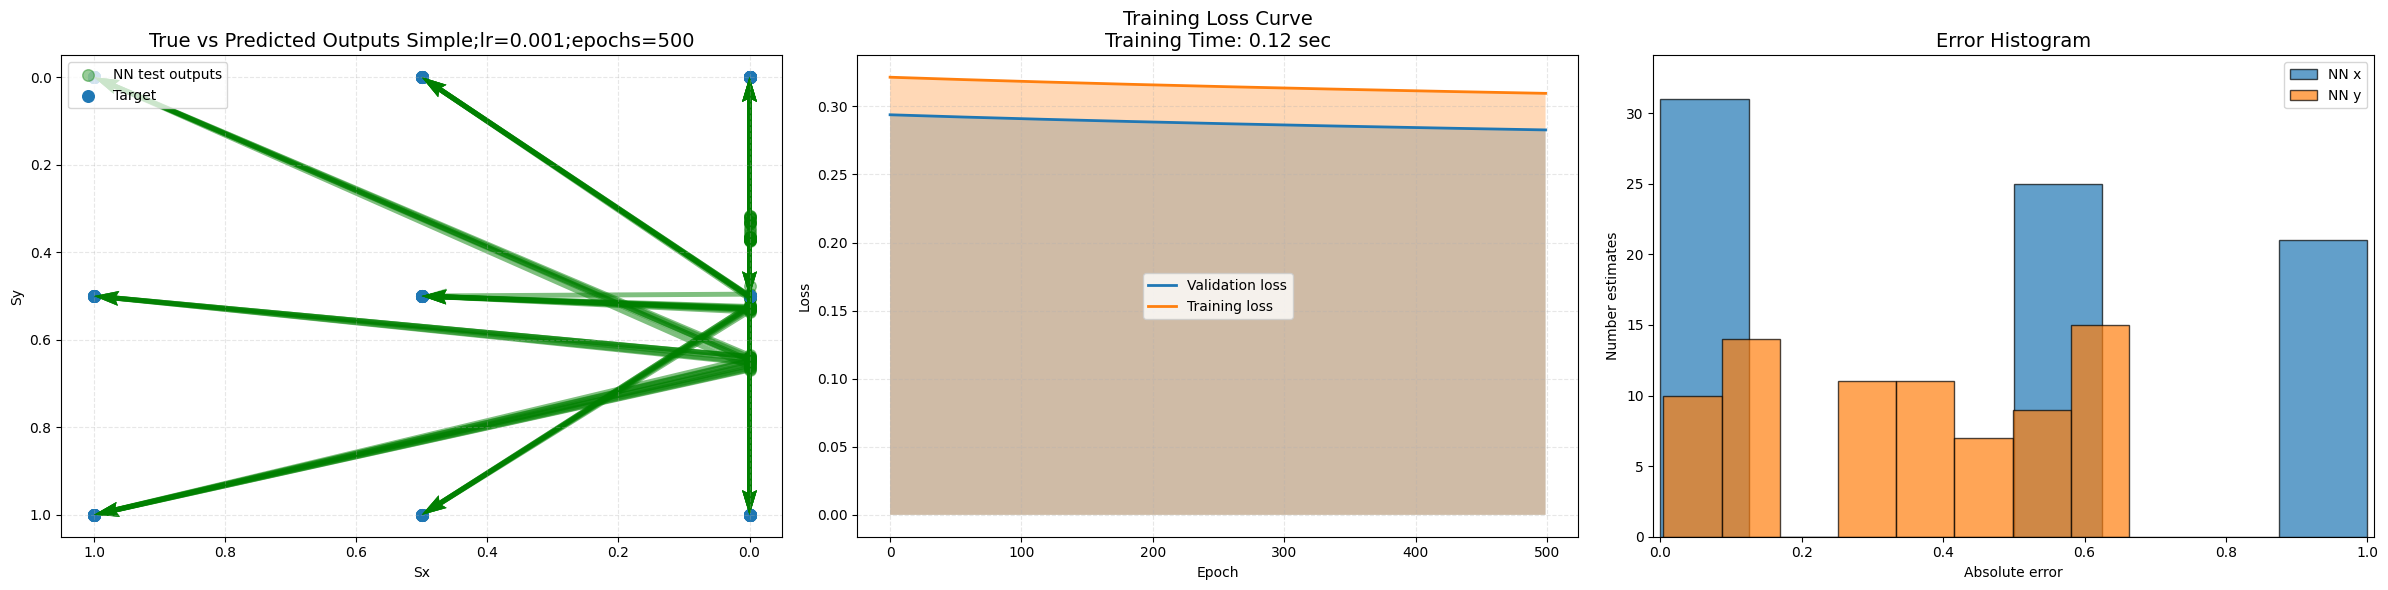

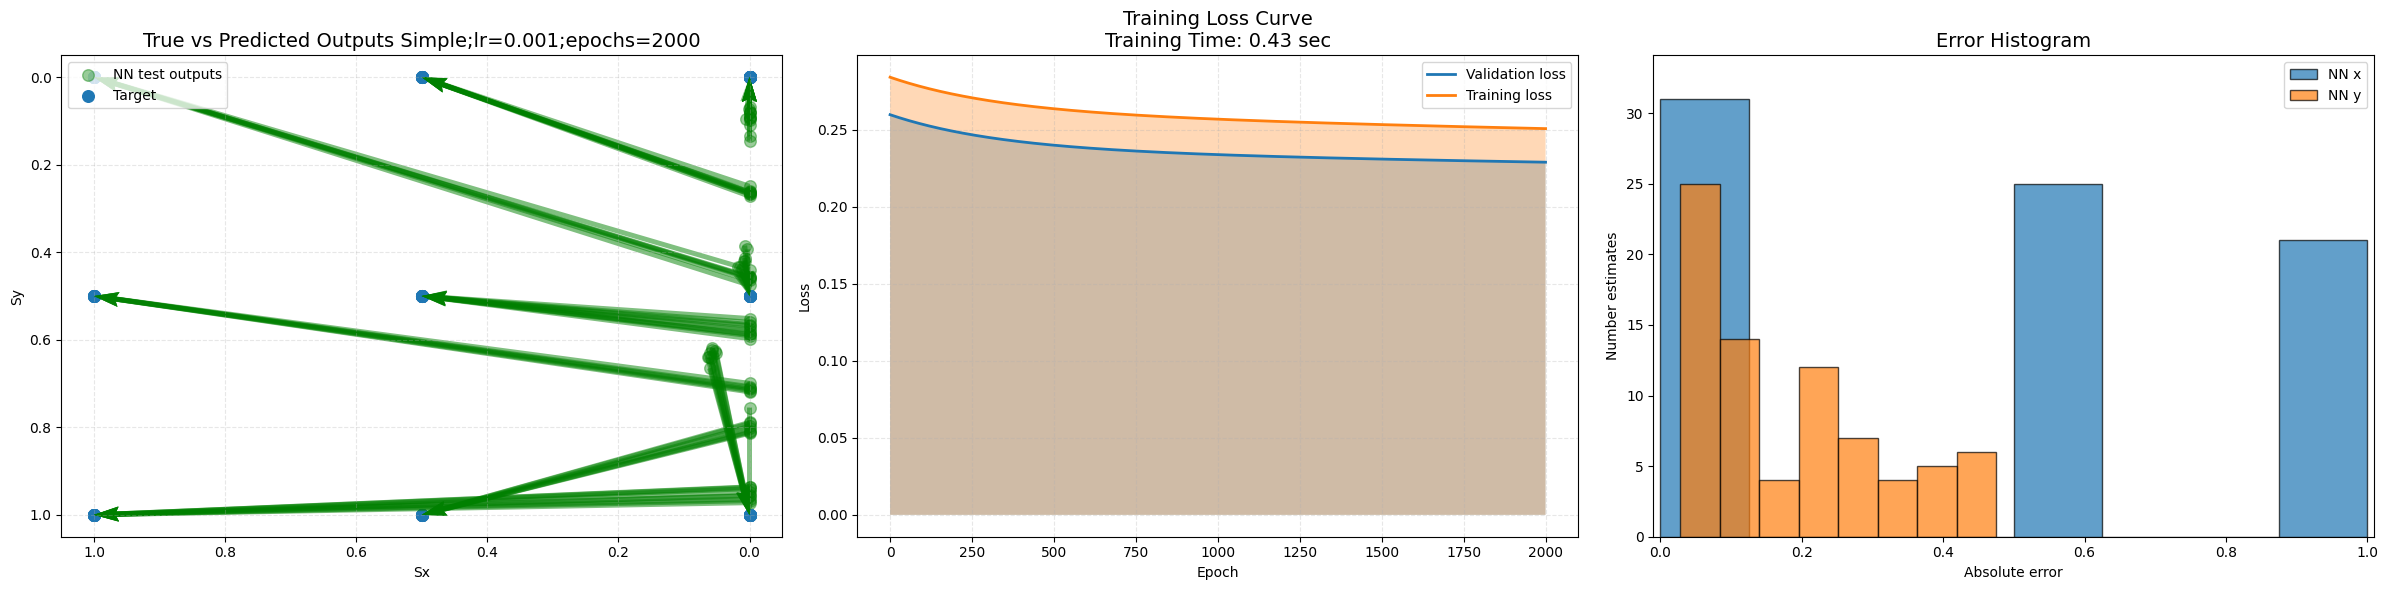

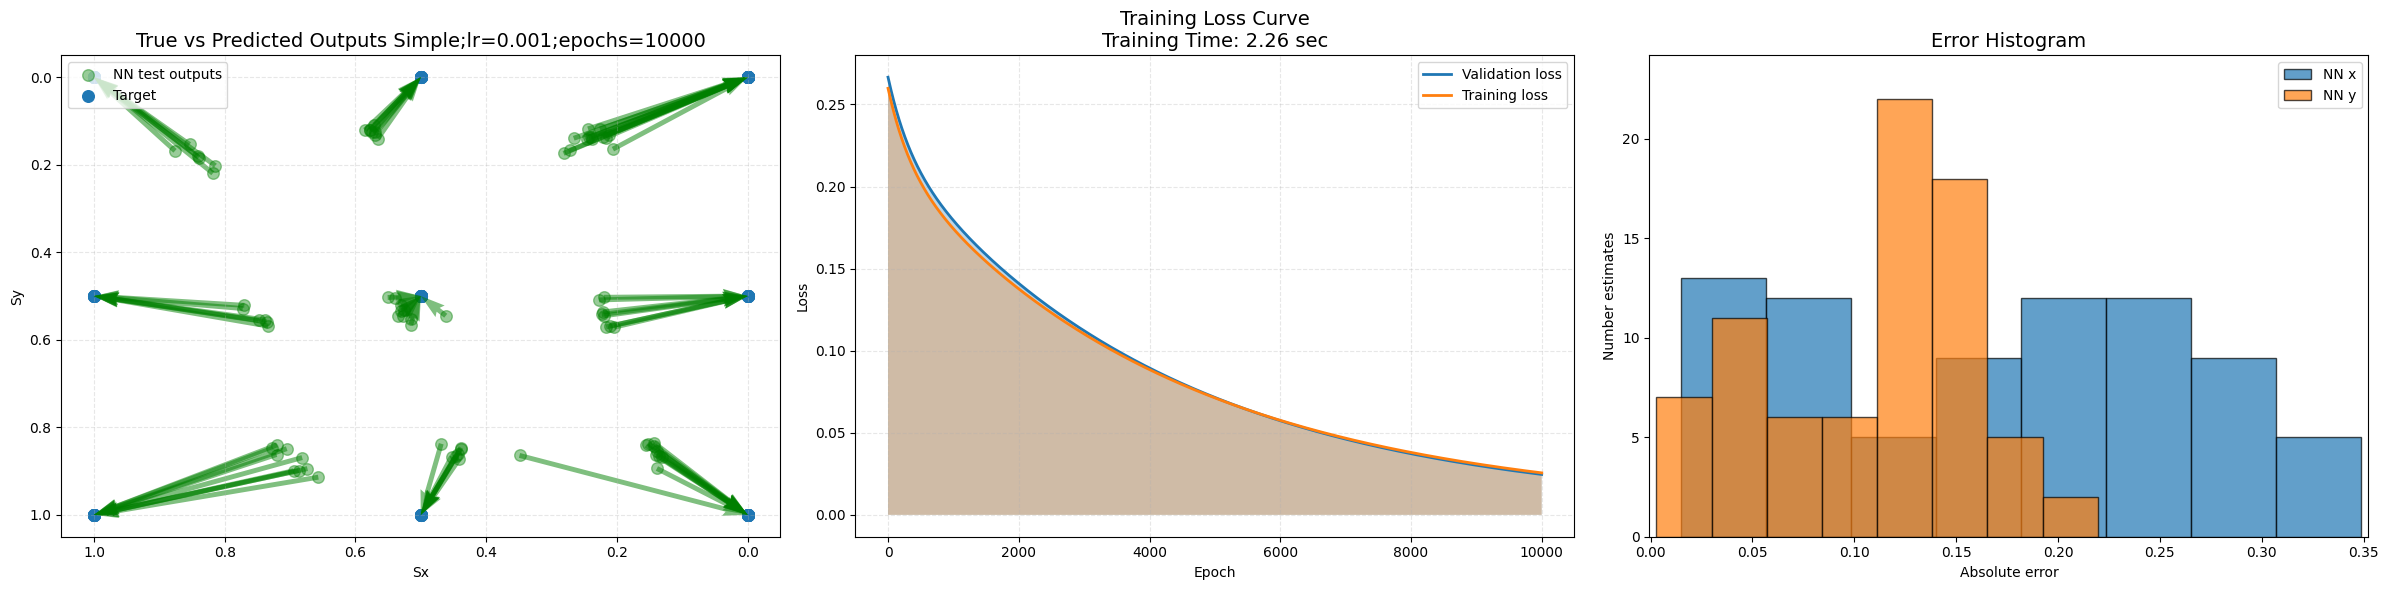

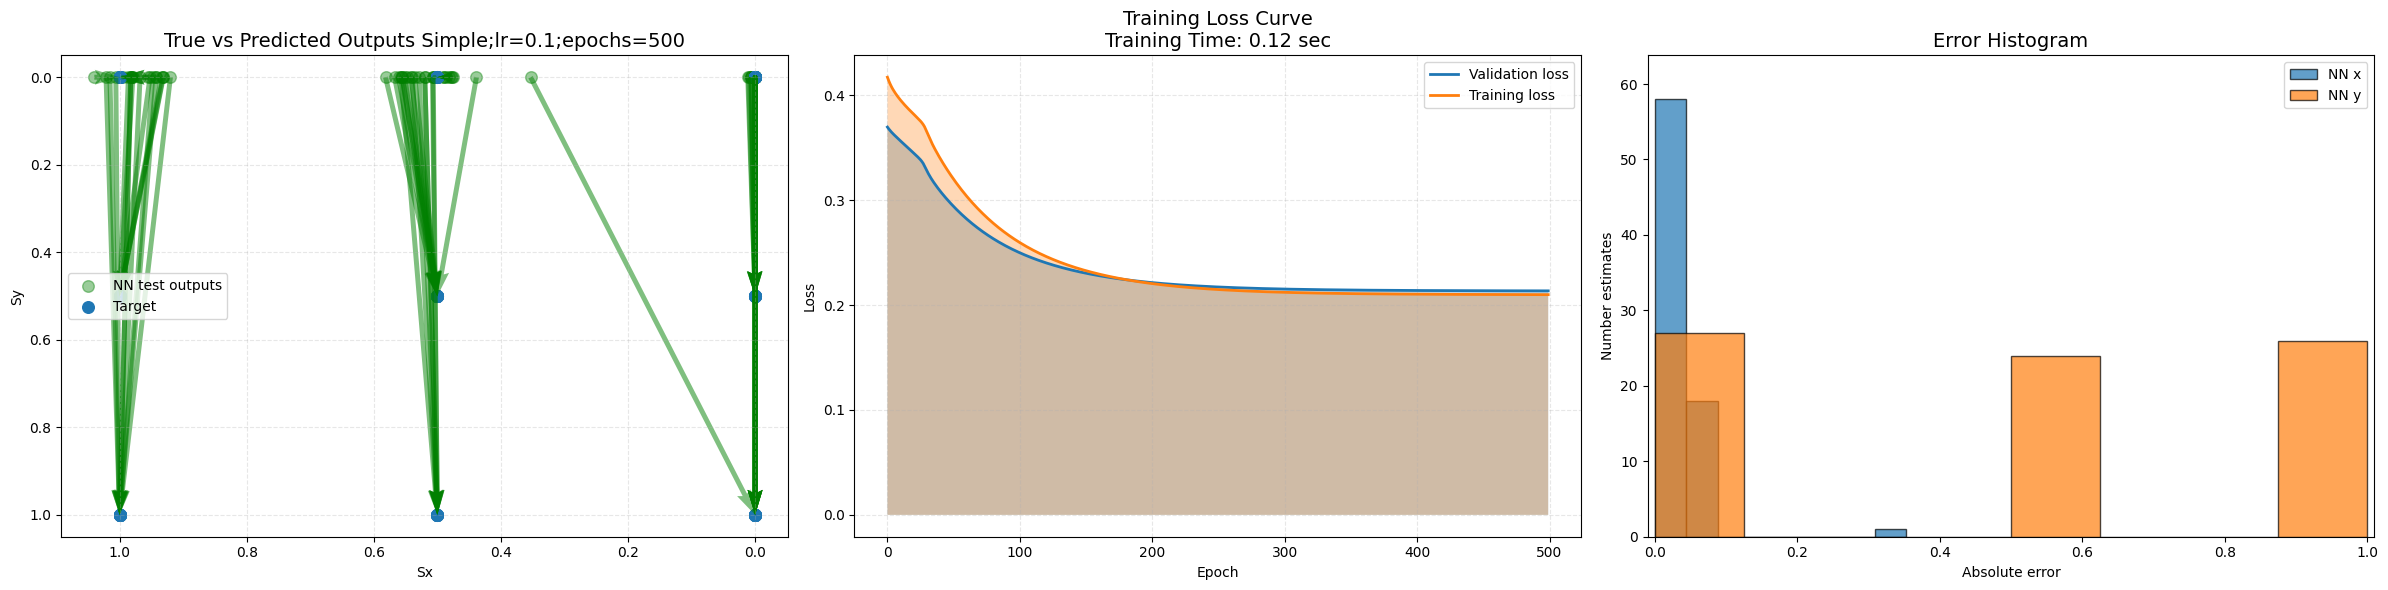

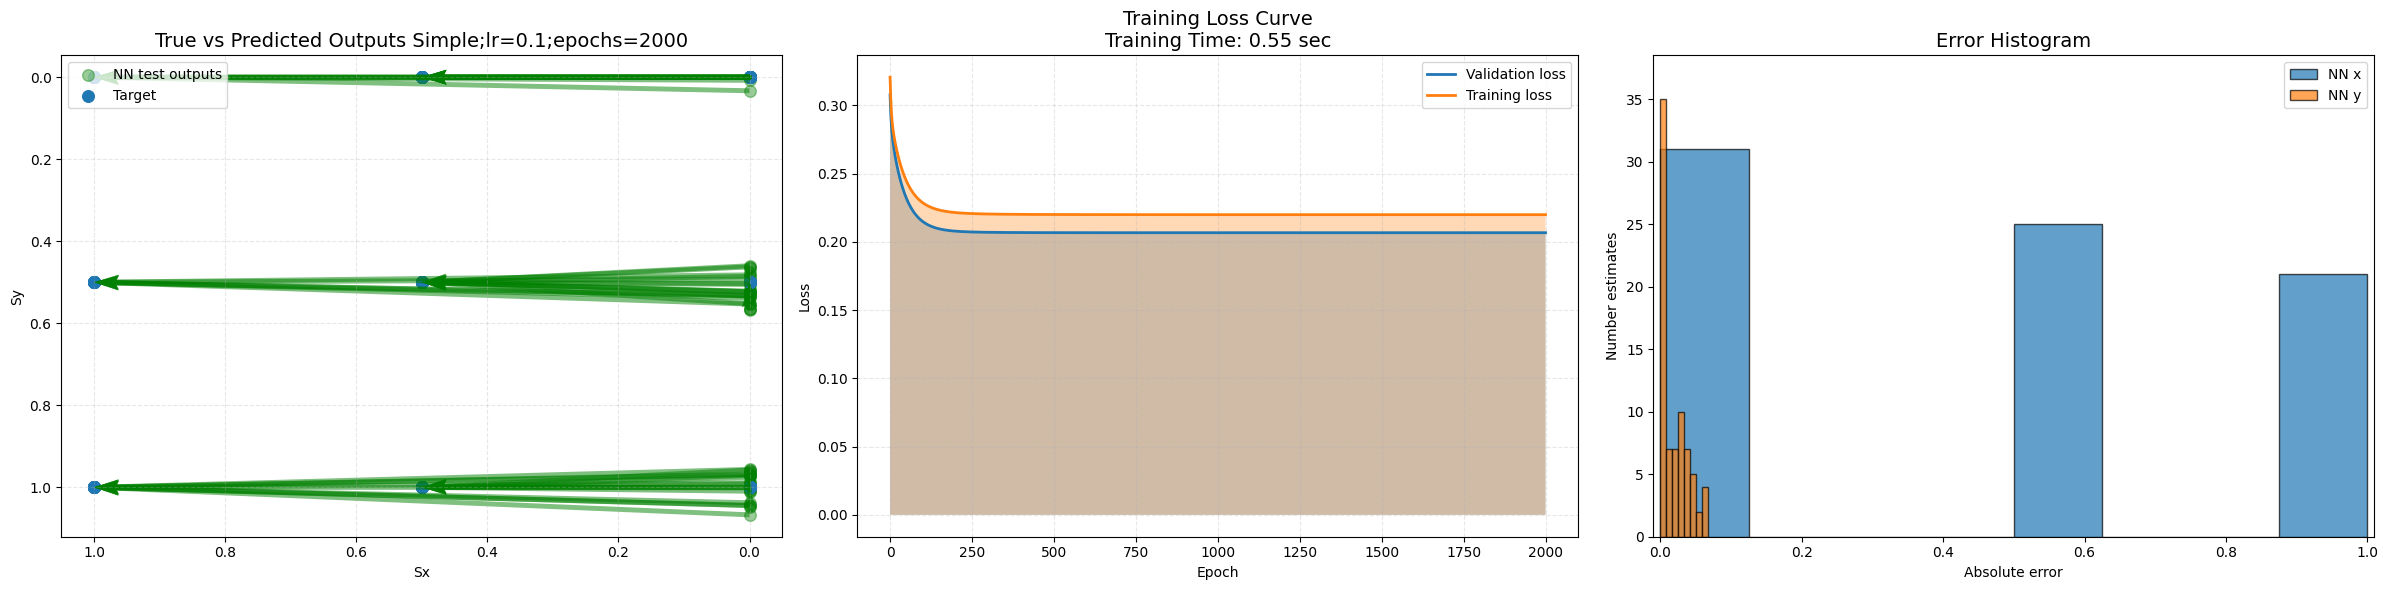

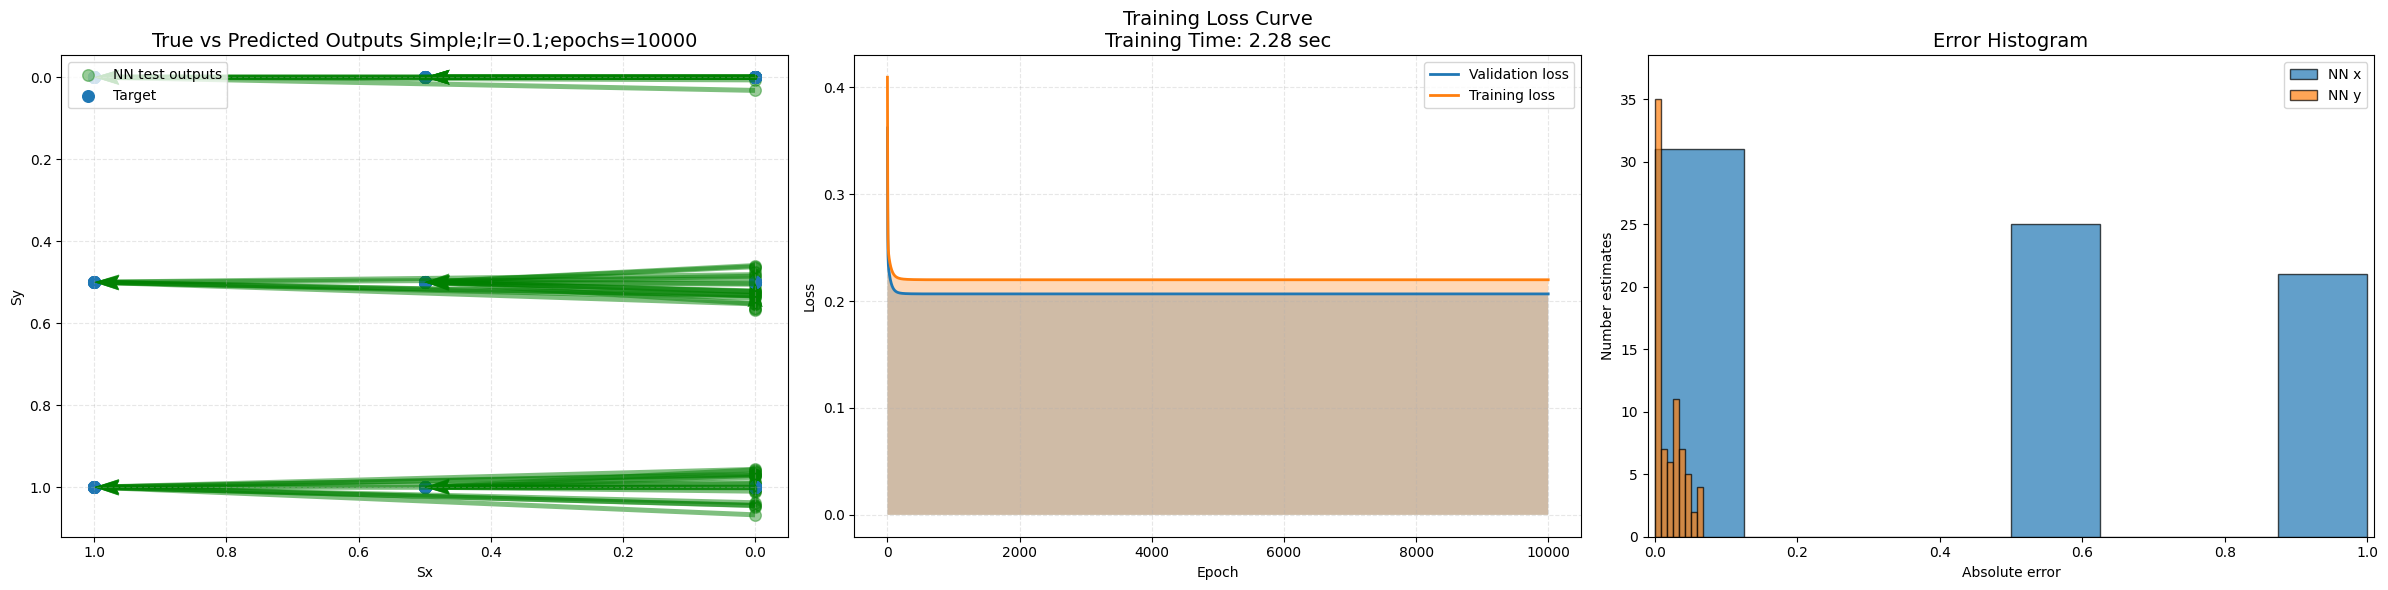

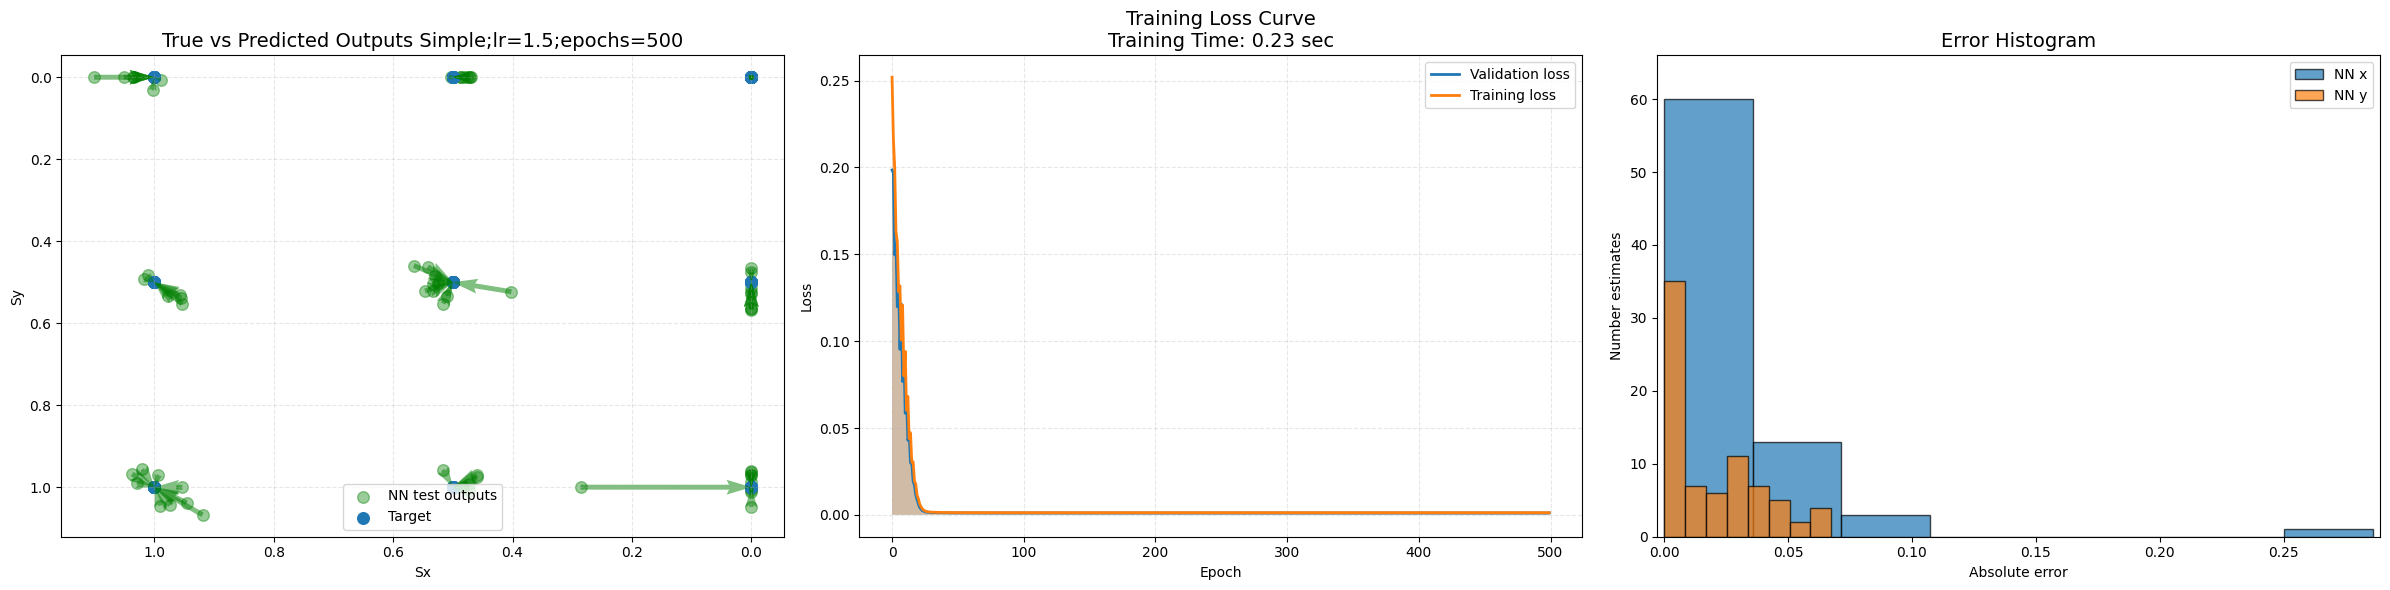

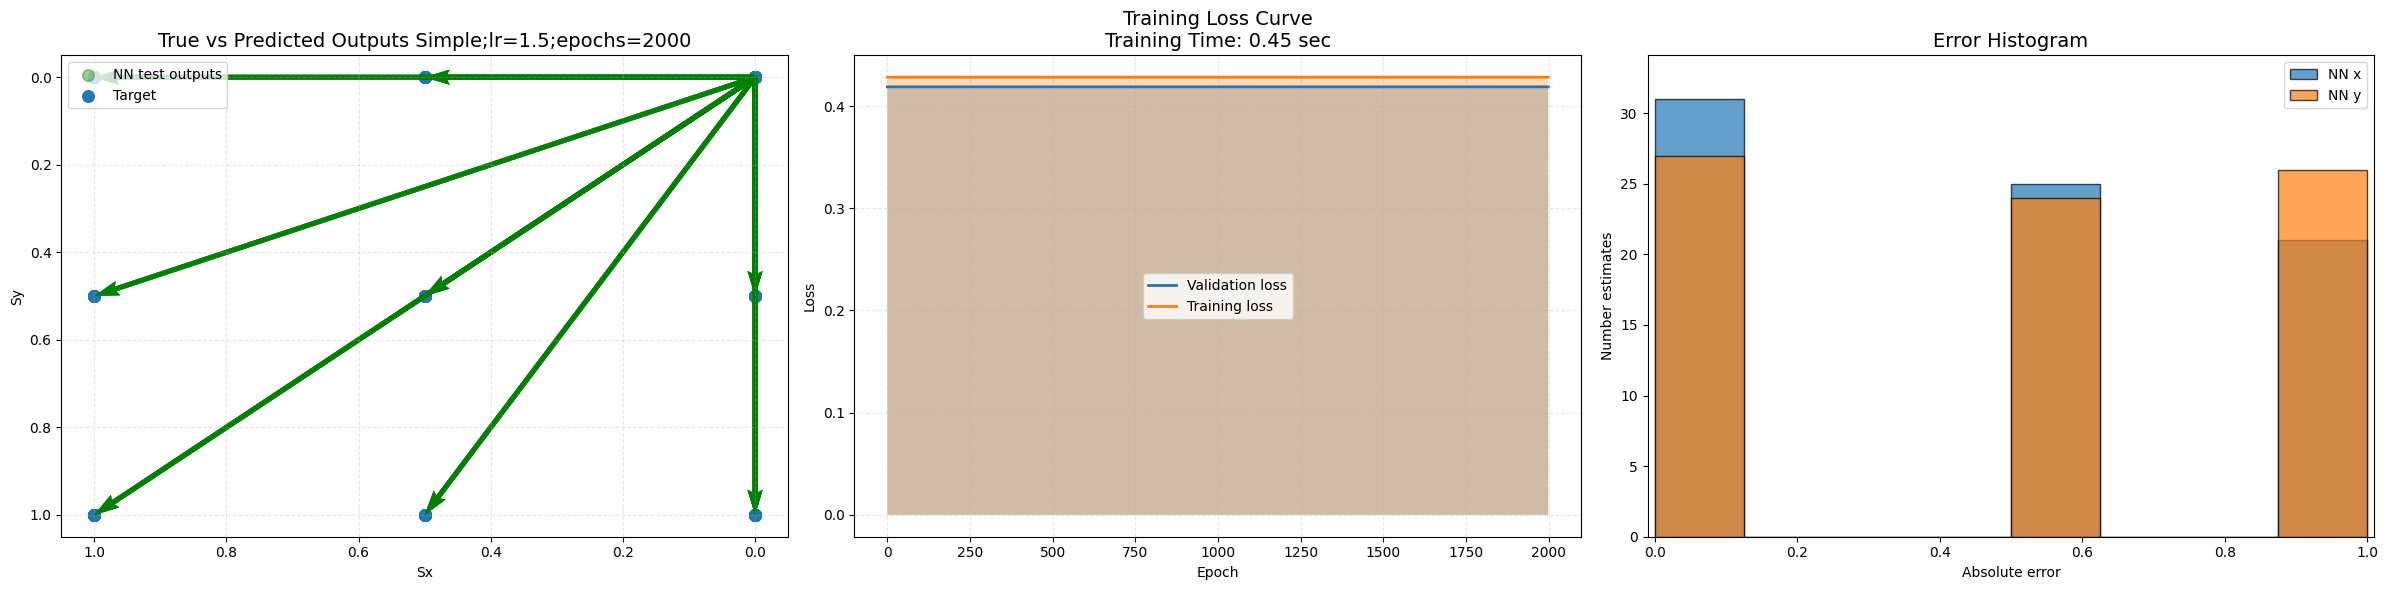

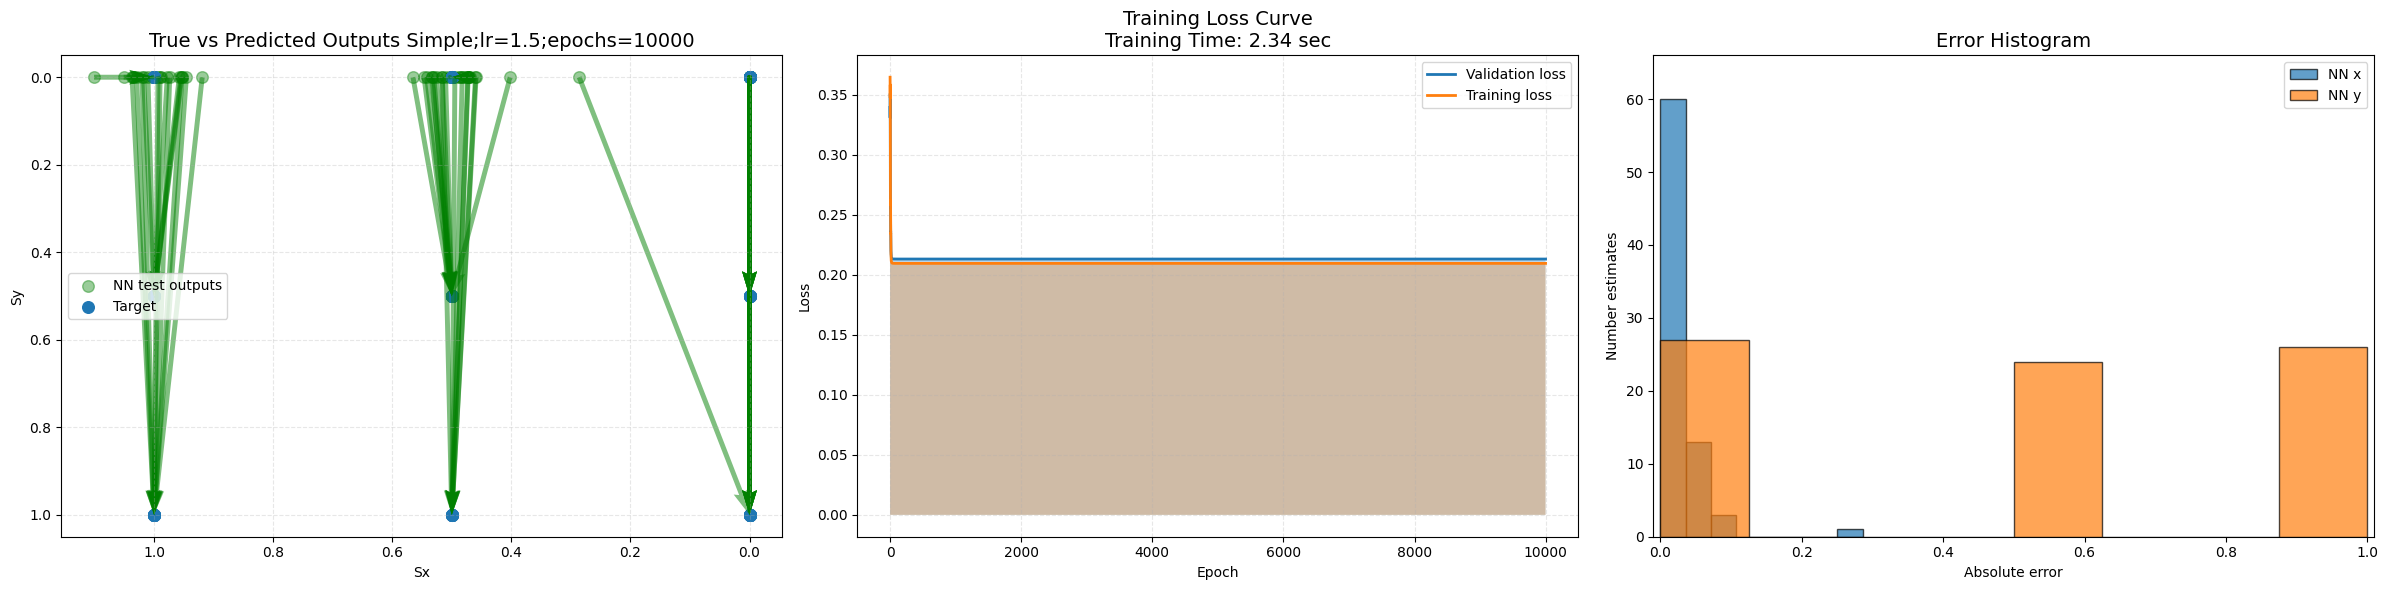

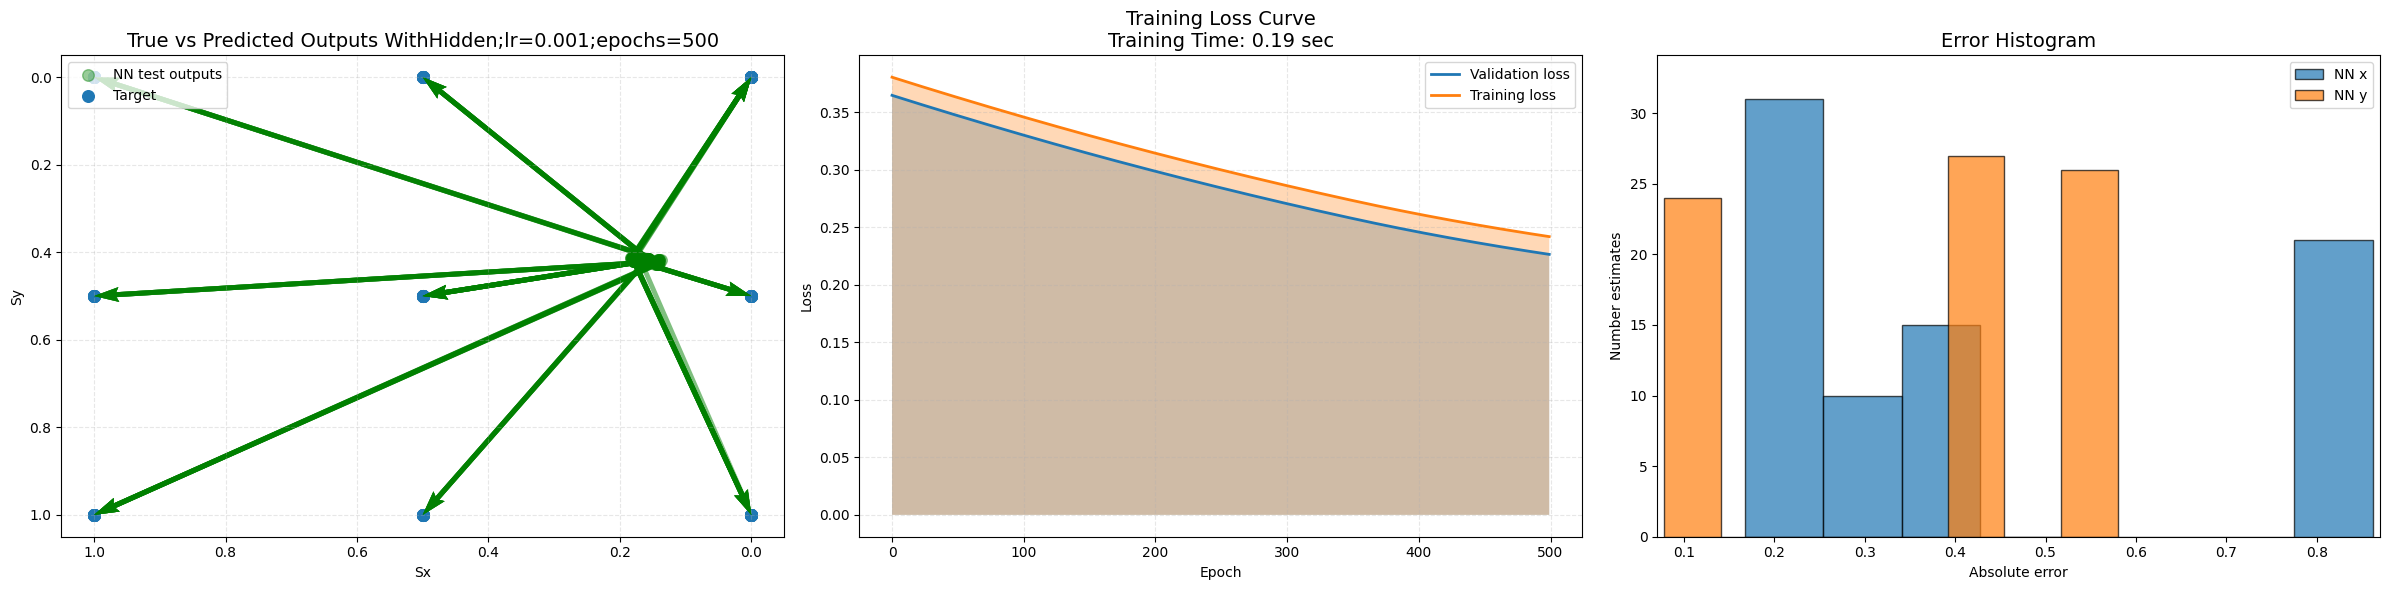

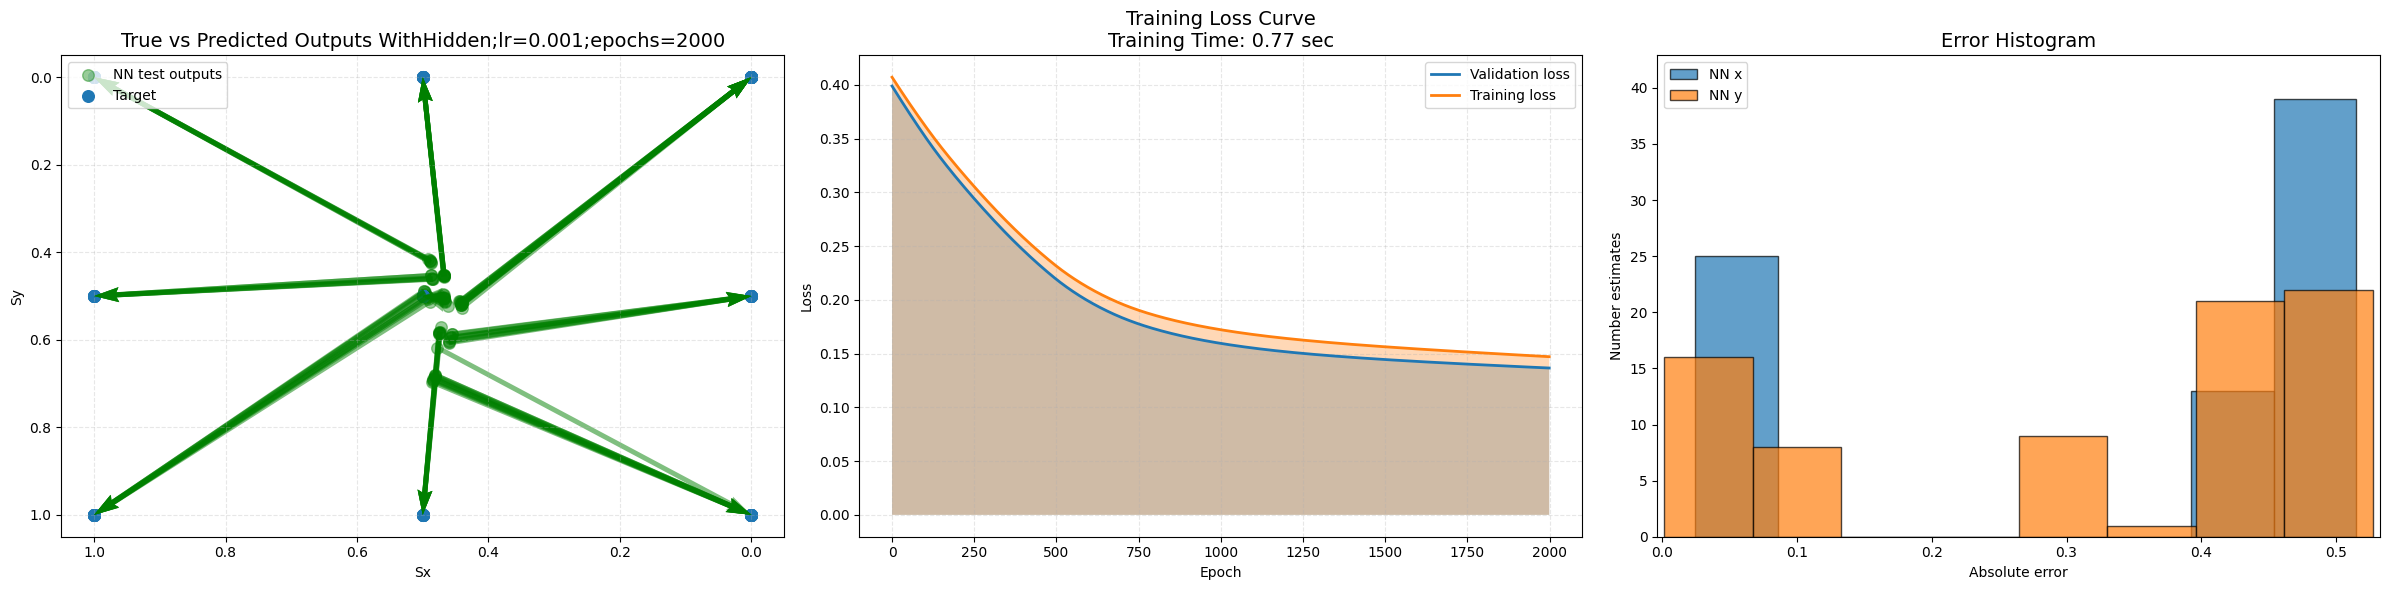

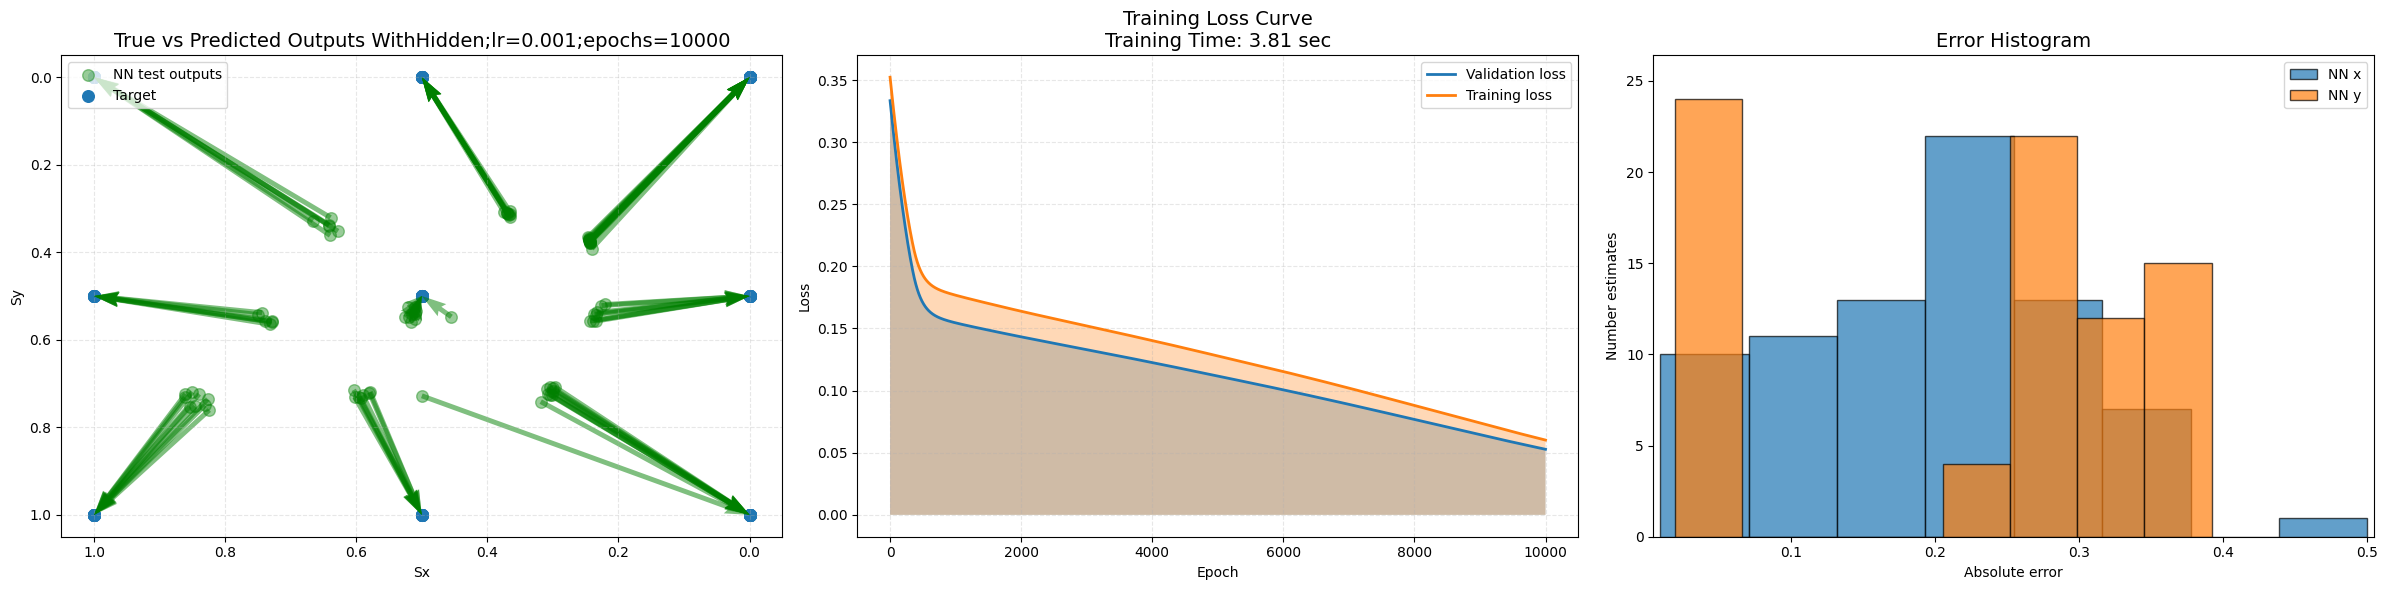

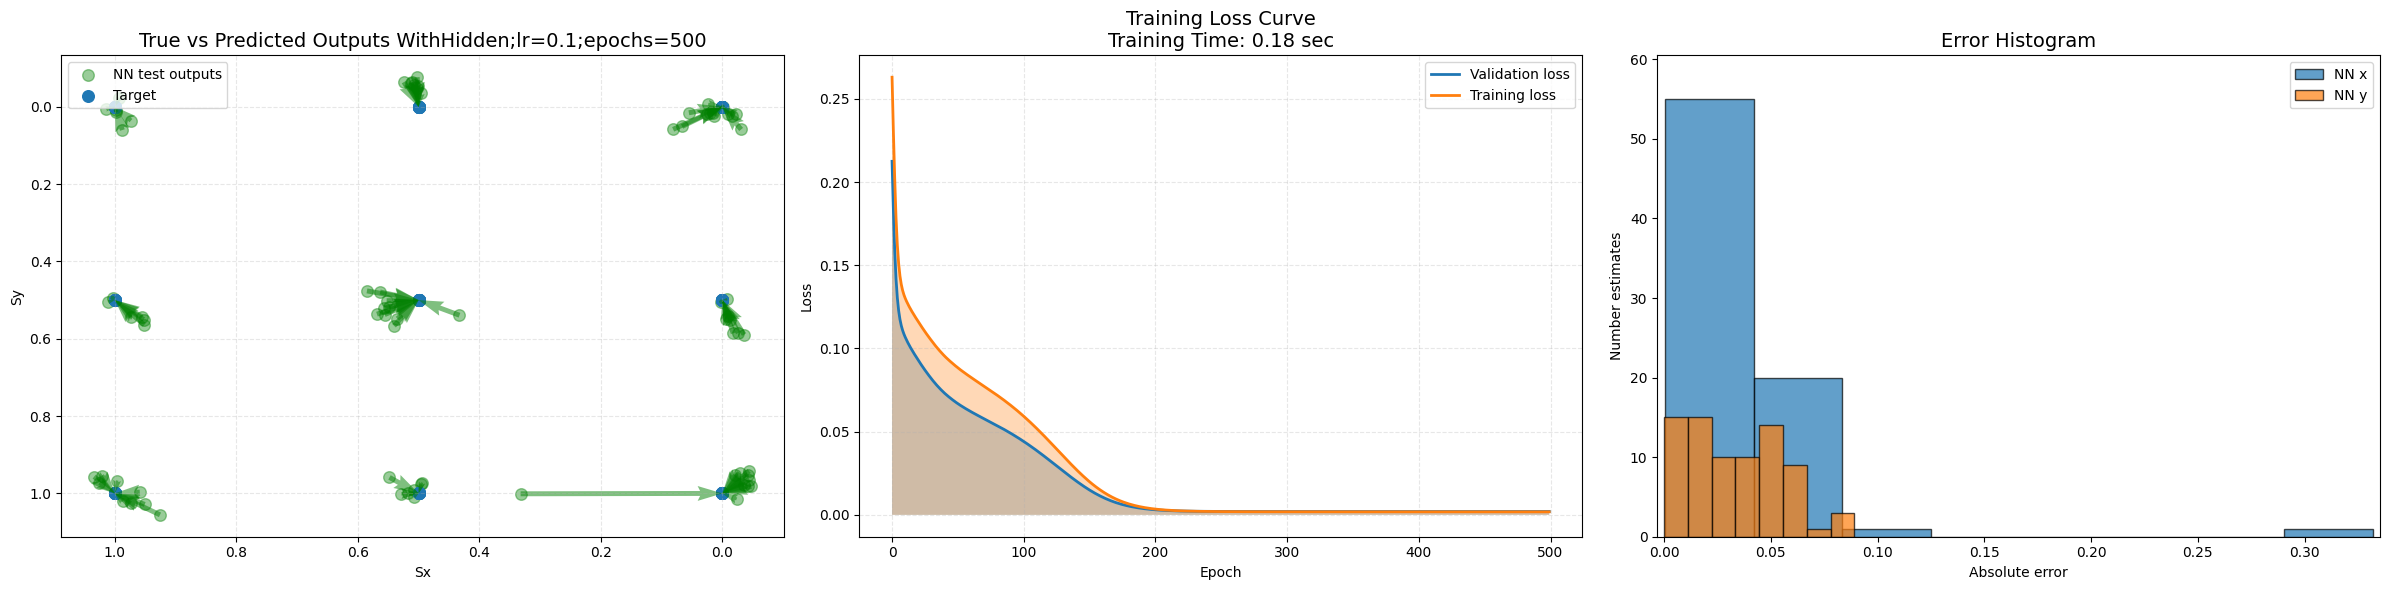

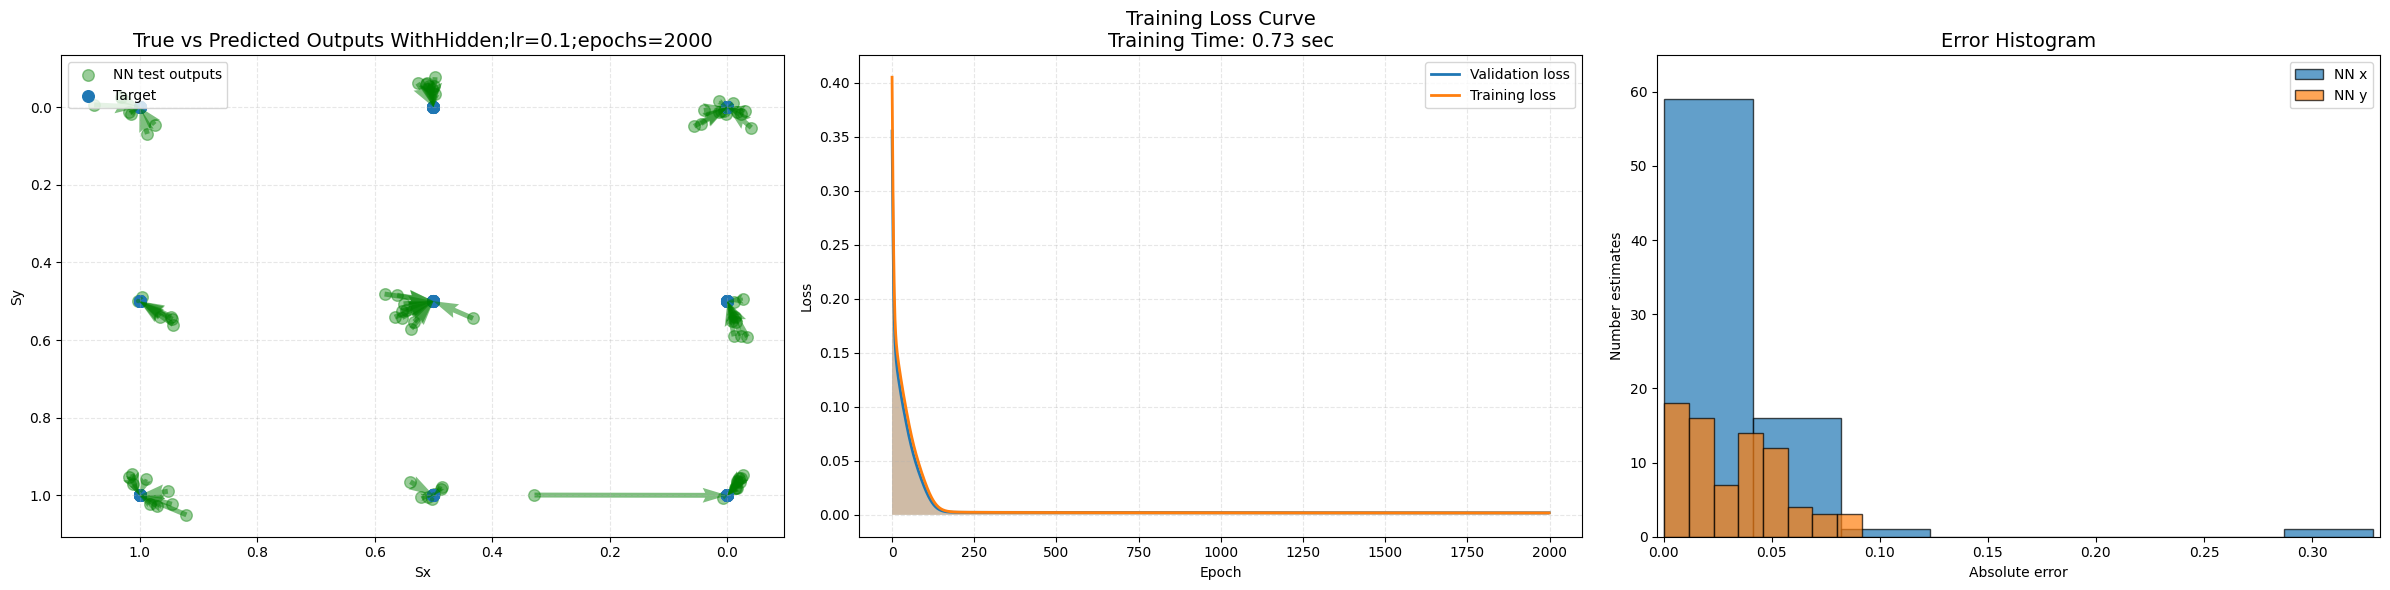

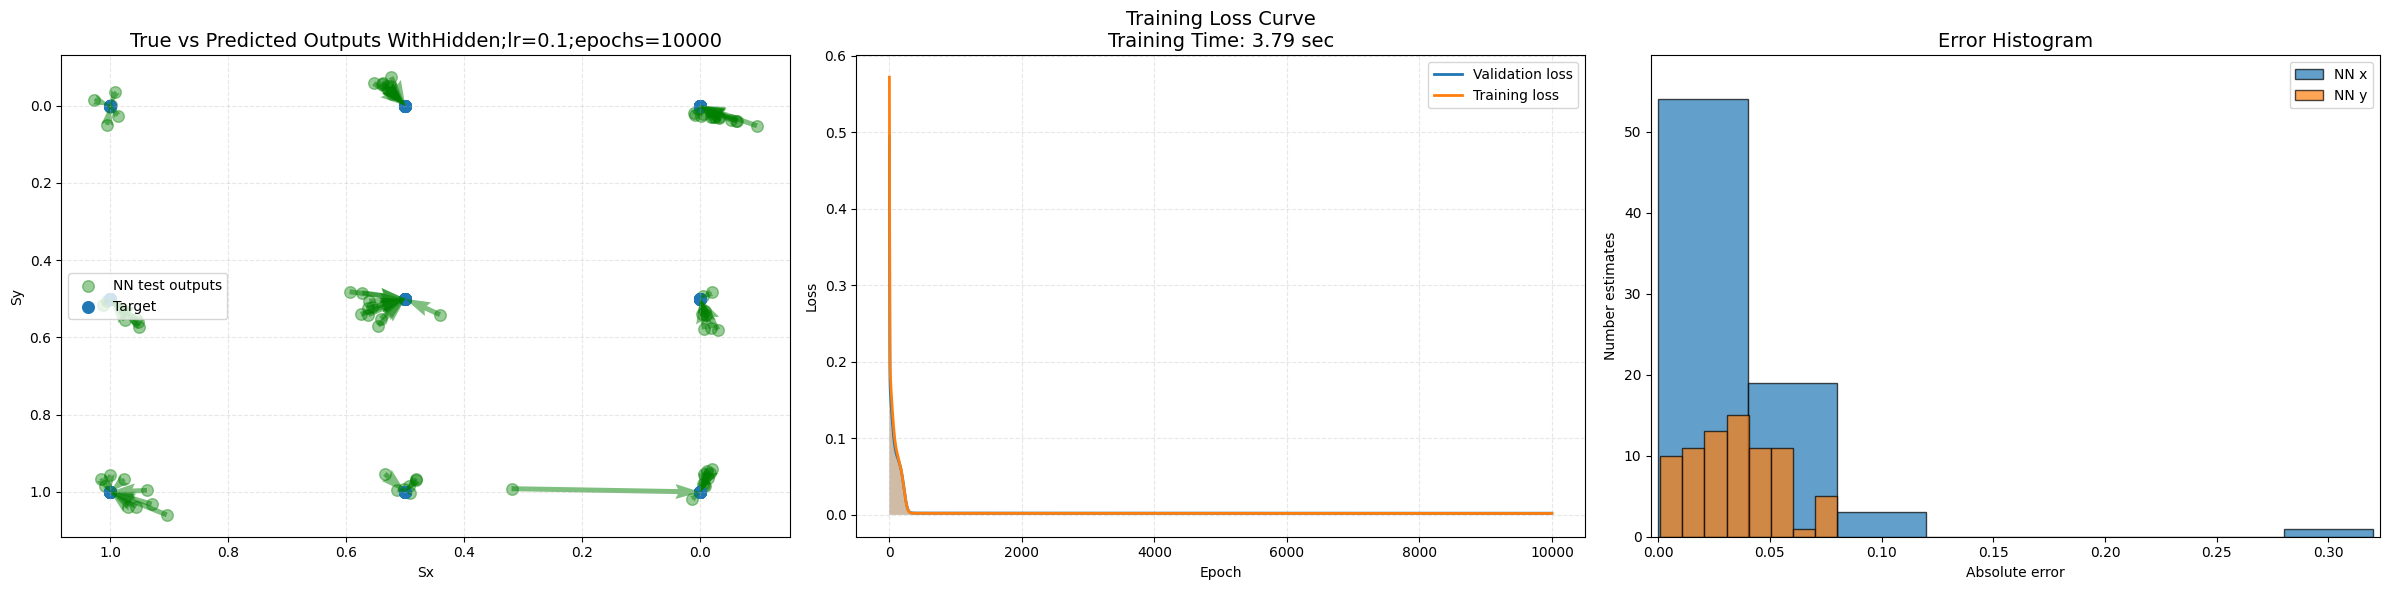

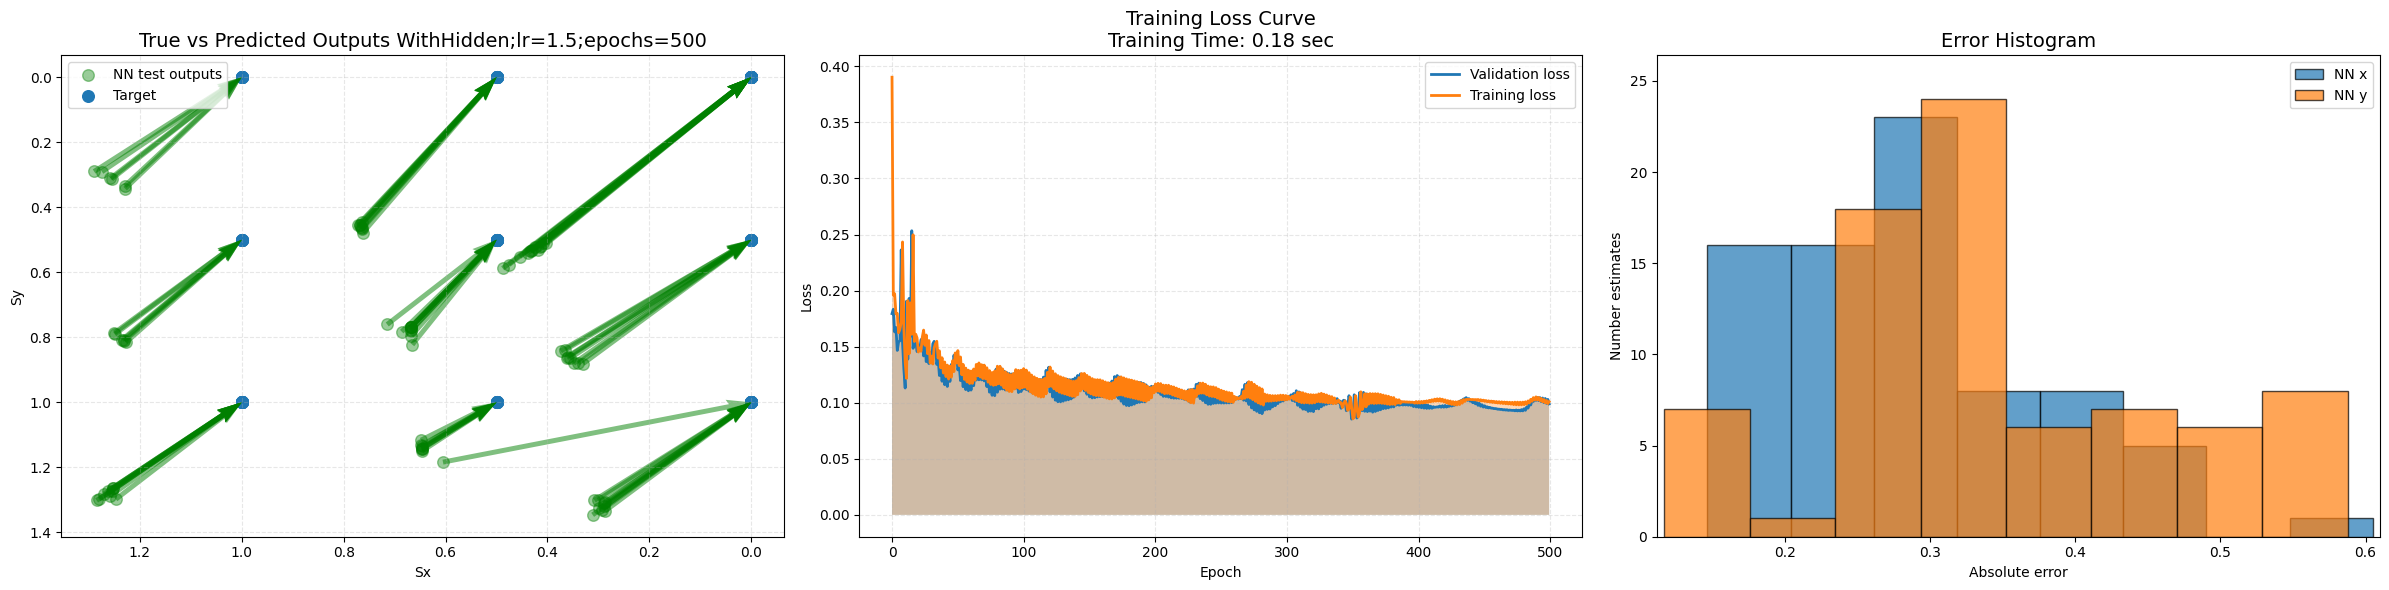

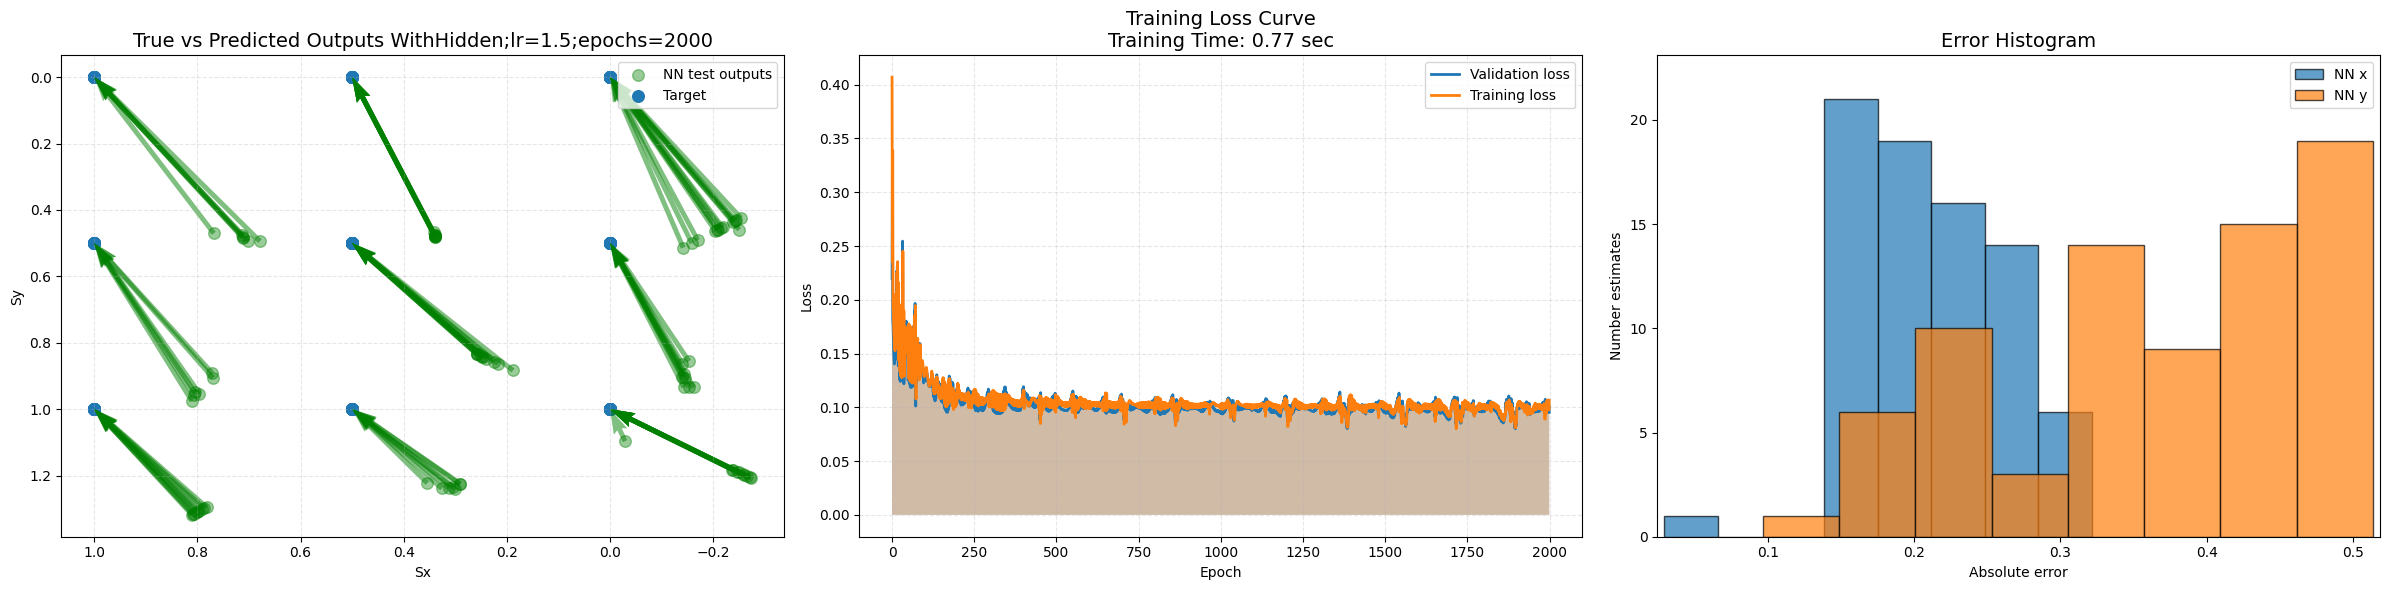

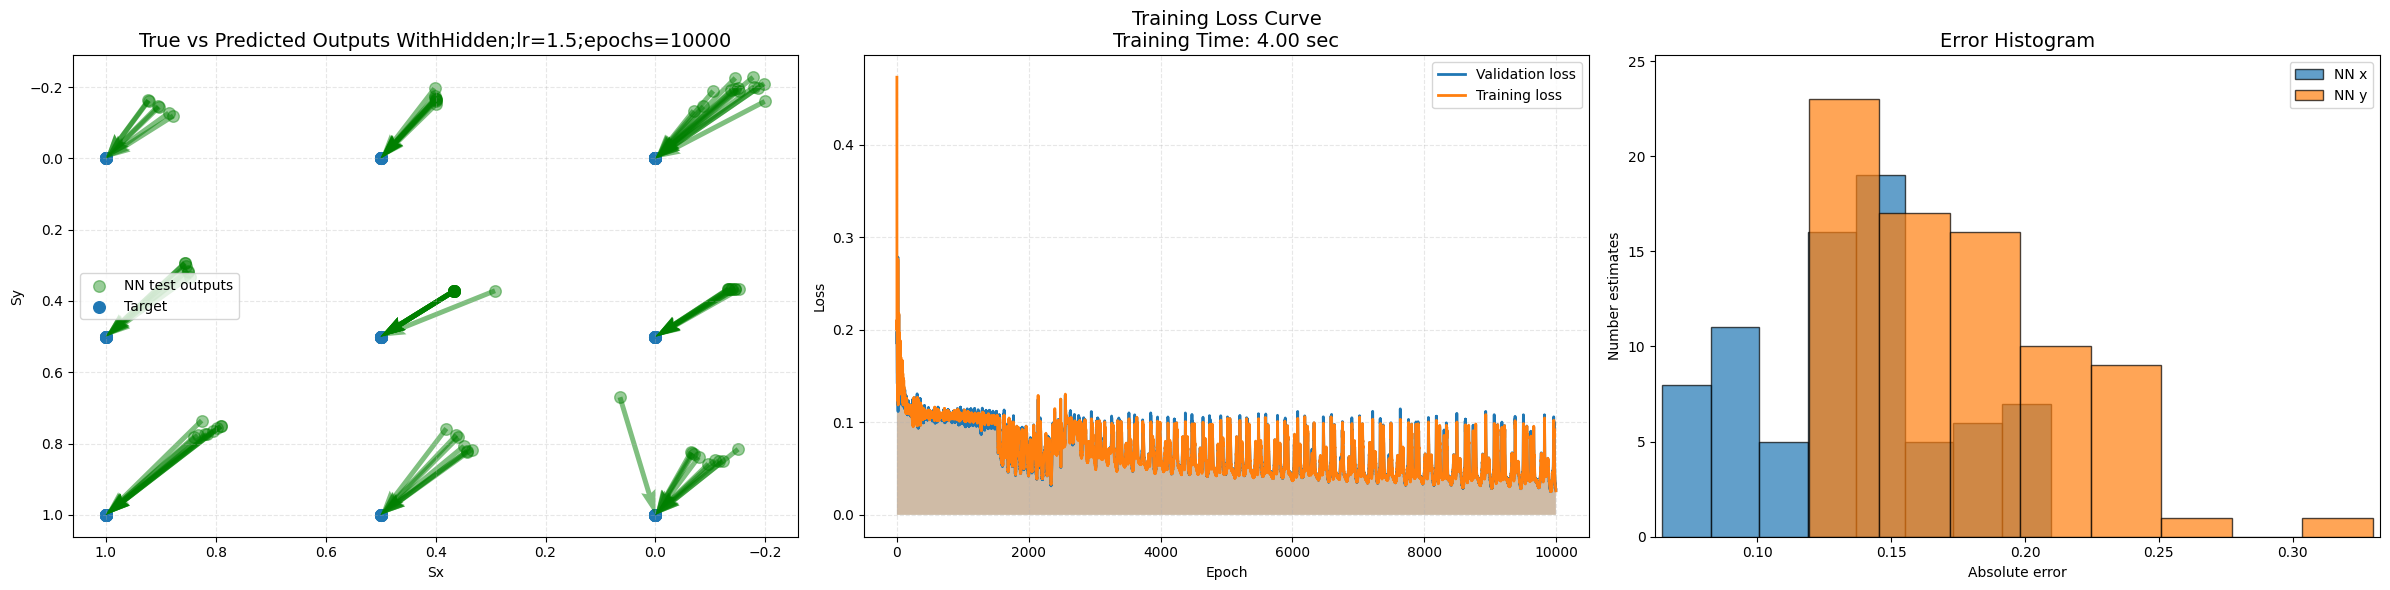

In [19]:
nn_util.plot_results_collected(
    Y_test_tensor_norm, pred_norm_arc,
    errors_norm_arc, models_dict_arc,
    losses_dict_arc, losses_val_dict_arc, training_time_dict_arc
)


---
**Task 11 (easy): Reflect on the results💡**
1. Do more/less complex models improve the result? Why/why not?
2. Are there indications of overfitting in any of the models?


---

## Task 11: Reflect on the Results

### 1. Do more/less complex models improve the result? Why/why not?

**More complex models (MLP with hidden layers) typically do NOT improve results for this linear gaze estimation problem:**

- **Linear relationship**: Gaze estimation is fundamentally a linear mapping from pupil to screen coordinates. Adding non-linear layers doesn't help when the underlying relationship is linear.

- **Overfitting risk**: More complex models (more layers/neurons) have more parameters, increasing the risk of overfitting to training noise rather than learning the true relationship.

- **Linear model is optimal**: For linear problems, a simple linear model (LinearModel) is theoretically optimal. Additional complexity adds no benefit and may hurt performance.

**Why simpler is better:**
- Linear models have fewer parameters, reducing overfitting risk
- They converge faster and more reliably
- They match the problem's linear nature
- Less computational cost

### 2. Are there indications of overfitting in any of the models?

**Signs of overfitting to look for:**

- **Gap between training and validation loss**: If training loss is much lower than validation loss, the model is memorizing training data rather than generalizing.

- **Gap between validation and test loss**: If validation loss is lower than test loss, the model may have been tuned to validation data.

- **Complex models performing worse**: More complex models (MLPs) showing higher test error than simple linear models suggests overfitting.

**For this problem:**
- Linear models typically show similar training/validation/test losses (no overfitting)
- Complex MLPs may show lower training loss but higher validation/test loss (overfitting)
- The best model is usually the simplest one that matches the problem complexity


---
**Task 12 (easy): Analyse results💡**
1. Experiment with other architectures by suggesting models with different number layers and neurons in each layer.
**Note:** This part of the exercise can easily become a timesink, mind your time as you proceed.


2. Reflect on the results    - Do more/less complex models improve the result? Why/why not?
    - Do any of the models show signs of overfitting?




---

In [0]:
# Write your reflections here...

## Own dataset
Experiment with your own dataset and other models. 
**Note:** For the exam it may be convenient to copy your code from task [Task 7](#prediction100) to the cell below.
This part of the exercise can easily become a timesink, mind your time as you proceed.


---
**Task 13 (easy): Train models (own dataset)👩‍💻💡**
1. Experiment with your own dataset. 
2. Reflect on your results, compare to the results of `test_subject_1`
. 


---